In [ ]:
# ============================
# Robustness & generality demo + Visuals  (revised)
# ============================
import numpy as np
from scipy.stats import rankdata
from sklearn.linear_model import TweedieRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.isotonic import IsotonicRegression
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
import lightgbm as lgb

import torch
import torch.nn as nn
import torch.optim as optim
from fast_soft_sort.pytorch_ops import soft_sort
import tweedie as tw

import matplotlib.pyplot as plt

# -----------------------------
# Utilities
# -----------------------------
def normalized_gini_numpy(y, mu):
    y, mu = np.asarray(y), np.asarray(mu)
    n = len(y)
    r_mu = rankdata(mu, method="ordinal")
    r_y  = rankdata(y,  method="ordinal")
    num = np.sum(y * r_mu)/np.sum(y) - (n+1)/2
    den = np.sum(y * r_y)/np.sum(y) - (n+1)/2
    return num/den

def soft_ranks_torch(scores, tau=0.01):
    n = scores.size(0)
    s_sorted = soft_sort(scores.unsqueeze(0), regularization_strength=tau).squeeze(0)
    C = -torch.abs(scores.unsqueeze(1) - s_sorted.unsqueeze(0))
    P = torch.softmax(C / tau, dim=1)
    idx = torch.arange(1., n + 1, device=P.device, dtype=P.dtype)
    return P.matmul(idx)

def smooth_gini_torch(y, mu, tau=0.01):
    n = y.size(0)
    r_mu = soft_ranks_torch(mu, tau)
    # CHANGE: target ranks don't need grads; stabilize denom
    with torch.no_grad():
        r_y  = soft_ranks_torch(y,   tau)
    num = (y * r_mu).sum()/y.sum() - (n+1)/2
    den = (y * r_y).sum()/y.sum() - (n+1)/2
    return num/(den + 1e-12)  # CHANGE: epsilon

# -----------------------------
# Models
# -----------------------------
class GiniNet(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(dim, 16), nn.ReLU(),
            nn.Linear(16, 16), nn.ReLU(),
            nn.Linear(16, 1)
        )
    def forward(self, x):
        return self.net(x).squeeze(-1)

# CHANGE: factor training to return a trained model once (no double-training)
def train_nn_gini_model(X_tr, y_tr, device="cpu", epochs=200, lr=1e-3):
    net = GiniNet(X_tr.shape[1]).to(device)
    opt = optim.Adam(net.parameters(), lr=lr)
    Xb_tr = torch.tensor(X_tr, device=device)
    yb_tr = torch.tensor(y_tr, device=device)
    for _ in range(epochs):
        net.train()
        opt.zero_grad()
        loss = -smooth_gini_torch(yb_tr, net(Xb_tr))
        loss.backward()
        opt.step()
    net.eval()
    return net

def predict_with_net(net, X, device="cpu"):
    with torch.no_grad():
        return net(torch.tensor(X, device=device)).cpu().numpy()

# CHANGE: add an MSE-aligned baseline NN
class MSENet(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(dim, 16), nn.ReLU(),
            nn.Linear(16, 16), nn.ReLU(),
            nn.Linear(16, 1)
        )
    def forward(self, x):
        return self.net(x).squeeze(-1)

def train_nn_mse_model(X_tr, y_tr, device="cpu", epochs=200, lr=1e-3, batch_size=512):
    net = MSENet(X_tr.shape[1]).to(device)
    opt = optim.Adam(net.parameters(), lr=lr)
    loss_fn = nn.MSELoss()
    Xb = torch.tensor(X_tr, device=device)
    yb = torch.tensor(y_tr, device=device)
    for _ in range(epochs):
        net.train()
        idx = torch.randperm(Xb.size(0), device=device)
        for s in range(0, Xb.size(0), batch_size):
            b = idx[s:s+batch_size]
            opt.zero_grad()
            loss = loss_fn(net(Xb[b]), yb[b])
            loss.backward()
            opt.step()
    net.eval()
    return net

# -----------------------------
# Data Generators
# -----------------------------
def gen_linear(n=6000, d=3, rho=1.5, phi=1.0, seed=0):
    rng = np.random.default_rng(seed)
    X = rng.uniform(0, 1, size=(n, d))
    w = np.linspace(0.5, 1.5, d)
    mu = np.exp(X @ w)
    Y  = tw.tweedie(mu=mu, p=rho, phi=phi).rvs(random_state=seed)
    return X.astype(np.float32), Y.astype(np.float32), mu.astype(np.float32)

def F_case11(x1, x2):
    return np.exp(-5*(1-x1)**2 + x2**2) + np.exp(-5*(x1**2) + (1-x2)**2)

def gen_nonlinear(n=6000, rho=1.5, phi=1.0, seed=0):
    rng = np.random.default_rng(seed)
    X = rng.uniform(0, 1, size=(n, 2))
    x1, x2 = X[:,0], X[:,1]
    mu = np.exp(F_case11(x1, x2))
    Y  = tw.tweedie(mu=mu, p=rho, phi=phi).rvs(random_state=seed)
    return X.astype(np.float32), Y.astype(np.float32), mu.astype(np.float32)

def gen_contaminated(n=6000, d=3, rho=1.5, phi=1.0, contam=0.1, seed=0):
    X, Y, mu = gen_linear(n, d, rho, phi, seed)
    rng = np.random.default_rng(seed)
    idx = rng.choice(n, int(contam*n), replace=False)
    Y[idx] *= 10.0
    return X, Y, mu

def gen_lognormal(n=6000, d=3, seed=0, nonlinear=False):
    rng = np.random.default_rng(seed)
    X = rng.uniform(0, 1, size=(n, d))
    if nonlinear and d == 2:
        mu = np.exp(np.sin(2*np.pi*X[:,0]) + np.cos(2*np.pi*X[:,1]))
    else:
        w = np.linspace(0.5, 1.5, d)
        mu = np.exp(X @ w)
    sigma = 0.5
    Y = rng.lognormal(mean=np.log(mu), sigma=sigma)
    return X.astype(np.float32), Y.astype(np.float32), mu.astype(np.float32)

# Linear generator with explicit SNR via Tweedie's phi
def gen_linear_snr(n=6000, d=3, rho=1.5, phi=1.0, seed=0):
    """
    Lower phi -> higher SNR, higher phi -> lower SNR (variance scales with phi).
    """
    rng = np.random.default_rng(seed)
    X = rng.uniform(0, 1, size=(n, d))
    w = np.linspace(0.5, 1.5, d)
    mu = np.exp(X @ w)
    Y  = tw.tweedie(mu=mu, p=rho, phi=phi).rvs(random_state=seed)
    return X.astype(np.float32), Y.astype(np.float32), mu.astype(np.float32)

# -----------------------------
# Experiment runner
# -----------------------------
def run_once(X, Y, test_size=0.5, seed=42, device="cpu"):
    # Base split
    X_tr, X_te, y_tr, y_te = train_test_split(X, Y, test_size=test_size, random_state=seed)

    # CHANGE: add calibration split (used ONLY for isotonic on the Gini pipeline)
    X_tr2, X_cal, y_tr2, y_cal = train_test_split(X_tr, y_tr, test_size=0.2, random_state=seed)

    results = {}

    # Tweedie GLM
    glm = TweedieRegressor(power=1.5, link='log', alpha=0.0, max_iter=2000)
    glm.fit(X_tr, y_tr)
    y_glm = glm.predict(X_te)
    results['TweedieGLM'] = (
        mean_squared_error(y_te, y_glm),
        mean_absolute_error(y_te, y_glm),
        normalized_gini_numpy(y_te, y_glm)
    )

    # CHANGE: NN-MSE baseline
    mse_net = train_nn_mse_model(X_tr, y_tr, device=device, epochs=200, lr=1e-3, batch_size=512)
    y_pred_mse = predict_with_net(mse_net, X_te, device=device)
    results['NN_MSE'] = (
        mean_squared_error(y_te, y_pred_mse),
        mean_absolute_error(y_te, y_pred_mse),
        normalized_gini_numpy(y_te, y_pred_mse)
    )

    # CHANGE: Train Gini net ONCE, predict for calib & test
    gnet = train_nn_gini_model(X_tr2, y_tr2, device=device, epochs=200, lr=1e-3)
    y_pred_gini_cal = predict_with_net(gnet, X_cal, device=device)
    y_pred_gini_te  = predict_with_net(gnet, X_te,  device=device)

    results['NN_Gini'] = (
        mean_squared_error(y_te, y_pred_gini_te),
        mean_absolute_error(y_te, y_pred_gini_te),
        normalized_gini_numpy(y_te, y_pred_gini_te)
    )

    # CHANGE: Isotonic fitted on calibration split, evaluated on test
    iso = IsotonicRegression(out_of_bounds='clip')
    iso.fit(y_pred_gini_cal, y_cal)
    y_iso = iso.transform(y_pred_gini_te)
    results['NN_Gini_Isotonic'] = (
        mean_squared_error(y_te, y_iso),
        mean_absolute_error(y_te, y_iso),
        normalized_gini_numpy(y_te, y_iso)
    )

    # LightGBM (deterministic)
    lgbm = lgb.LGBMRegressor(objective="tweedie", tweedie_variance_power=1.5,
                             n_estimators=300, force_col_wise=True, verbose=-1,
                             random_state=seed)  # CHANGE: random_state
    lgbm.fit(X_tr, y_tr)
    y_lgb = lgbm.predict(X_te)
    results['LightGBM'] = (
        mean_squared_error(y_te, y_lgb),
        mean_absolute_error(y_te, y_lgb),
        normalized_gini_numpy(y_te, y_lgb)
    )

    # Random Forest (already seeded)
    rf = RandomForestRegressor(n_estimators=200, random_state=seed)
    rf.fit(X_tr, y_tr)
    y_rf = rf.predict(X_te)
    results['RandomForest'] = (
        mean_squared_error(y_te, y_rf),
        mean_absolute_error(y_te, y_rf),
        normalized_gini_numpy(y_te, y_rf)
    )

    return results

def agg_over_seeds(gen_fn, seeds=range(5), device="cpu"):
    # CHANGE: include NN_MSE in the canonical order for consistency everywhere
    names = ['TweedieGLM','NN_MSE','NN_Gini','NN_Gini_Isotonic','LightGBM','RandomForest']  # CHANGE
    arrs = {k: [] for k in names}
    all_runs = []
    for s in seeds:
        X, Y, _ = gen_fn(seed=s)
        res = run_once(X, Y, seed=1234+s, device=device)
        all_runs.append(res)
        for k in names:
            arrs[k].append(res[k])
    avgs = {k: (np.mean(arrs[k], axis=0), np.std(arrs[k], axis=0)) for k in names}
    return avgs, all_runs, names  # CHANGE: return names for plotting order

def print_table(title, avgs, names=None):  # CHANGE: allow fixed order
    print(title)
    print(f"{'Model':<20} {'MSE':>15} {'MAD':>15} {'Norm-Gini':>15}")
    print("-"*70)
    items = ([(n, avgs[n]) for n in names] if names is not None else avgs.items())
    for name, (mean,std) in items:
        mse, mad, gini = mean
        smse, smad, sgini = std
        print(f"{name:<20} {mse:8.4f}±{smse:6.4f} {mad:8.4f}±{smad:6.4f} {gini:8.4f}±{sgini:6.4f}")
    print()

# -----------------------------
# Visualization helpers
# -----------------------------
def plot_metrics(title, avgs, names):  # CHANGE: use consistent order
    metrics = ["MSE", "MAD", "Norm-Gini"]
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    for j, metric in enumerate(metrics):
        means = [avgs[m][0][j] for m in names]
        stds  = [avgs[m][1][j] for m in names]
        axes[j].bar(names, means, yerr=stds, capsize=5)
        axes[j].set_title(f"{metric}")
        axes[j].tick_params(axis='x', rotation=45)
    fig.suptitle(title, fontsize=16)
    plt.tight_layout()
    plt.show()

def plot_boxplots(title, all_runs, names, metric_idx=2):  # default Norm-Gini
    data = {m: [r[m][metric_idx] for r in all_runs] for m in names}
    plt.figure(figsize=(10,6))
    plt.boxplot(data.values(), labels=data.keys(), showmeans=True)
    plt.ylabel(["MSE","MAD","Normalized Gini"][metric_idx])
    plt.title(f"{title} – Distribution across seeds")
    plt.xticks(rotation=45)
    plt.show()

# -----------------------------
# Run all scenarios with visuals
# -----------------------------
for scen, gen_fn in [
    ("Well-specified Tweedie GLM (linear mean):", lambda **kw: gen_linear(n=1000, d=3, rho=1.5, phi=1.0, **kw)),
    ("Mis-specified Tweedie GLM (nonlinear mean; Case 1.1):", lambda **kw: gen_nonlinear(n=1000, rho=1.5, phi=1.0, **kw)),
    ("Contaminated linear mean (10% outliers):", lambda **kw: gen_contaminated(n=1000, d=3, rho=1.5, phi=1.0, contam=0.1, **kw)),
    ("Non-Tweedie DGP: Lognormal (linear mean):", lambda **kw: gen_lognormal(n=1000, d=3, nonlinear=False, **kw)),
    ("High SNR (phi=0.2):", lambda **kw: gen_linear_snr(n=1000, d=3, rho=1.5, phi=0.2, **kw)),  # lower phi -> higher SNR
    ("Low SNR (phi=5.0):", lambda **kw: gen_linear_snr(n=1000, d=3, rho=1.5, phi=5.0, **kw)),   # higher phi -> lower SNR
]:
    avgs, all_runs, names = agg_over_seeds(gen_fn, seeds=range(5), device="cpu")
    print_table(scen, avgs, names=names)          # CHANGE: pass names for order
    plot_metrics(scen, avgs, names=names)         # CHANGE
    plot_boxplots(scen, all_runs, names=names)    # CHANGE


### Exp1

In [24]:
# ===============================================================
# RankNet (TensorFlow) vs GiniNet (PyTorch + fast_soft_sort)
# + Tweedie scenario
# + Pairwise accuracy by Y-quantile bins (10 bins, within-bin pairs)
# + Added: Gini-weighted RankNet (log-sigmoid smoothing)
# + Replaced lognormal / pareto with normal / gamma distributions
# ===============================================================

import os, numpy as np, pandas as pd, matplotlib.pyplot as plt
from numpy.random import default_rng
from scipy.stats import rankdata, spearmanr, kendalltau
from sklearn.model_selection import train_test_split

# -----------------------------
# Global seed (best-effort)
# -----------------------------
SEED = 2025
rng = default_rng(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)

# -----------------------------
# Metrics (shared)
# -----------------------------
def normalized_gini_numpy(y, mu):
    y, mu = np.asarray(y), np.asarray(mu)
    n = len(y)
    r_mu = rankdata(mu, method="ordinal")
    r_y  = rankdata(y,  method="ordinal")
    num = np.sum(y * r_mu)/np.sum(y) - (n+1)/2
    den = np.sum(y * r_y)/np.sum(y) - (n+1)/2
    return float(num/den)

def pairwise_accuracy(y, s, m=200_000, seed=SEED+3):
    rr = default_rng(seed)
    y = np.asarray(y); s = np.asarray(s)
    n = len(y)
    i = rr.integers(0, n, m); j = rr.integers(0, n, m)
    mask = i != j; i, j = i[mask], j[mask]
    return float(np.mean(np.sign(y[i]-y[j]) == np.sign(s[i]-s[j])))
'''
def pack_all_metrics(y_true, scores):
    acc = pairwise_accuracy(y_true, scores, m=200_000, seed=SEED+7)
    rho, _ = spearmanr(y_true, scores)
    tau, _ = kendalltau(y_true, scores)
    ng = normalized_gini_numpy(y_true, scores)
    return dict(PairAcc=acc, Spearman=rho, Kendall=tau, NormGini=ng)'''

def pack_all_metrics(y_true, scores):
    y_true = np.asarray(y_true); scores = np.asarray(scores)
    acc = pairwise_accuracy(y_true, scores, m=200_000, seed=SEED+7)
    rho, _ = spearmanr(y_true, scores)
    tau, _ = kendalltau(y_true, scores)
    ng = normalized_gini_numpy(y_true, scores)
    mse = float(np.mean((y_true - scores)**2))
    rmse = float(np.sqrt(mse))
    return dict(PairAcc=acc, Spearman=rho, Kendall=tau, NormGini=ng,
                MSE=mse, RMSE=rmse)


# -----------------------------
# Region / bin accuracy helpers
# -----------------------------
def acc_within_quantile_region(y, s, qlo, qhi, m=200_000, seed=SEED+11):
    """
    Pairwise accuracy for pairs whose BOTH labels fall in Y-quantile [qlo, qhi].
    """
    rr = default_rng(seed)
    y = np.asarray(y); s = np.asarray(s); n = len(y)
    lo = np.quantile(y, qlo); hi = np.quantile(y, qhi)
    idx = np.where((y >= lo) & (y <= hi))[0]
    if idx.size < 2: return np.nan
    i = rr.choice(idx, size=m, replace=True)
    j = rr.choice(idx, size=m, replace=True)
    mask = i != j; i, j = i[mask], j[mask]
    return float(np.mean(np.sign(y[i]-y[j]) == np.sign(s[i]-s[j])))

def acc_by_y_quantile_bins(y, s, n_bins=10, m=200_000, seed=SEED+17):
    """
    Pairwise accuracy for pairs drawn entirely within each Y-quantile bin.
    Returns DataFrame with one row per Y-decile bin.
    """
    rr = default_rng(seed)
    y = np.asarray(y); sc = np.asarray(s); n = len(y)
    qs = np.quantile(y, np.linspace(0,1,n_bins+1))
    # ensure last bin includes max
    qs[-1] = np.nextafter(qs[-1], np.inf)
    rows = []
    for k in range(n_bins):
        lo, hi = qs[k], qs[k+1]
        idx = np.where((y >= lo) & (y < hi))[0]
        if idx.size < 2:
            rows.append({"ybin":k, "q_low": (k)/n_bins, "q_high": (k+1)/n_bins,
                         "count": int(idx.size), "PairAcc": np.nan})
            continue
        i = rr.choice(idx, size=m, replace=True)
        j = rr.choice(idx, size=m, replace=True)
        mask = i != j; i, j = i[mask], j[mask]
        acc = float(np.mean(np.sign(y[i]-y[j]) == np.sign(sc[i]-sc[j])))
        rows.append({"ybin":k, "q_low": (k)/n_bins, "q_high": (k+1)/n_bins,
                     "count": int(idx.size), "PairAcc": acc})
    return pd.DataFrame(rows)

def acc_by_gap_deciles(y, s, n_bins=10, m=300_000, seed=SEED+13):
    """
    Accuracy vs |ΔY| deciles (reference). Returns DataFrame with per-gap bin accuracy.
    """
    rr = default_rng(seed)
    y = np.asarray(y); sc = np.asarray(s); n = len(y)
    i = rr.integers(0, n, m); j = rr.integers(0, n, m); mask = i != j
    i, j = i[mask], j[mask]
    gaps = np.abs(y[i] - y[j])
    qs = np.quantile(gaps, np.linspace(0,1,n_bins+1))
    qs[-1] = np.nextafter(qs[-1], np.inf)
    b = np.searchsorted(qs, gaps, side='right') - 1
    correct = np.sign(y[i]-y[j]) == np.sign(sc[i]-sc[j])
    rows = []
    for k in range(n_bins):
        msk = (b == k)
        rows.append({
            "gap_bin": k,
            "|ΔY|_low": qs[k],
            "|ΔY|_high": qs[k+1],
            "pairs": int(msk.sum()),
            "acc": float(correct[msk].mean()) if msk.any() else np.nan
        })
    return pd.DataFrame(rows)

# -----------------------------
# Data generators (incl. Tweedie-like)
# Replaced lognormal & pareto with:
#   - Normal regression
#   - Gamma regression
# -----------------------------
def gen_normal_regression(n=6000, d=10, sigma=1.0, seed=SEED):
    """
    Standard linear-Gaussian regression:
    X ~ N(0, I), w ~ N(0, I), y = Xw/sqrt(d) + ε, ε ~ N(0, sigma^2)
    """
    rr = default_rng(seed)
    X = rr.normal(size=(n, d))
    w = rr.normal(size=d)
    z = X @ w / np.sqrt(d)
    y = (z + rr.normal(scale=sigma, size=n)).astype(np.float32)
    return X.astype(np.float32), y

def gen_gamma_regression(n=6000, d=10, shape=2.0, seed=SEED):
    """
    Positive heavy-tailed regression:
    mu = exp(Xw/sqrt(d)), y ~ Gamma(shape, scale=mu/shape) so E[y]=mu.
    """
    rr = default_rng(seed)
    X = rr.normal(size=(n, d))
    w = rr.normal(size=d)
    mu = np.exp(X @ w / np.sqrt(d))
    y = rr.gamma(shape=shape, scale=mu/shape).astype(np.float32)
    return X.astype(np.float32), y

def gen_heteroskedastic_tail(n=6000, d=10, seed=SEED):
    rr = default_rng(seed)
    X = rr.normal(size=(n,d)); w = rr.normal(size=d)
    mu = np.exp(X @ w / np.sqrt(d))
    noise = rr.lognormal(mean=0.0, sigma=0.7, size=n) * (mu**0.5)
    y = (mu + noise).astype(np.float32)
    return X.astype(np.float32), y

def gen_exponential_mixture(n=6000, d=10, seed=SEED):
    rr = default_rng(seed)
    X = rr.normal(size=(n,d)); w = rr.normal(size=d)
    mu = np.exp(X @ w / np.sqrt(d))
    mix = rr.uniform(size=n) < 0.3  # 30% heavy
    y = rr.exponential(scale=1.0/(mu+1e-8))
    y[mix] += rr.exponential(scale=3.0/(mu[mix]+1e-8))
    y = (np.maximum(y, 1e-8)).astype(np.float32)
    return X.astype(np.float32), y

def gen_tweedie_like(n=6000, d=10, p=1.5, phi=1.0, seed=SEED):
    """
    Tweedie-like positive target with mean mu=exp(Xw).
    We mimic compound-Poisson–Gamma via a simple approximation.
    """
    rr = default_rng(seed)
    X = rr.normal(size=(n,d)); w = rr.normal(size=d)
    mu = np.exp(X @ w / np.sqrt(d))  # positive mean
    kappa = 1.0 / (phi + 1e-8)       # shape parameter
    gamma_scale = (phi * (mu**p)) / (kappa + 1e-8)
    G = rr.gamma(shape=kappa, scale=gamma_scale)
    y = np.power(G, 1.0/max(p, 1e-8)).astype(np.float32)
    return X.astype(np.float32), y

SCENARIOS = [
    ("Normal (σ=1.0)",          lambda seed: gen_normal_regression(n=6000, d=10, sigma=1.0, seed=seed)),
    ("Gamma (shape=2.0)",       lambda seed: gen_gamma_regression(n=6000, d=10, shape=2.0,  seed=seed)),
    ("Heteroskedastic tail",    lambda seed: gen_heteroskedastic_tail(n=6000, d=10, seed=seed)),
    ("Exponential mixture",     lambda seed: gen_exponential_mixture(n=6000, d=10, seed=seed)),
    ("Tweedie-like (p=1.5)",    lambda seed: gen_tweedie_like(n=6000, d=10, p=1.5, phi=1.0, seed=seed)),
]

# ===============================================================
# SECTION A — RankNet (TensorFlow/Keras) with per-epoch hooks
# + Gini-weighted RankNet (log-sigmoid smoothing)
# ===============================================================
import tensorflow as tf
from tensorflow.keras import layers, Model, Input
from tensorflow.nn import leaky_relu
tf.random.set_seed(SEED)

def make_random_pairs(X, y, num_pairs=250_000, seed=SEED):
    rr = default_rng(seed); n = len(y)
    i = rr.integers(0, n, num_pairs); j = rr.integers(0, n, num_pairs)
    mask = (i != j); i, j = i[mask], j[mask]
    Xi, Xj = X[i], X[j]
    t = (y[i] > y[j]).astype(np.float32)  # 1 if yi>yj else 0
    return (Xi, Xj), t

def make_random_pairs_weighted(X, y, num_pairs=250_000, seed=SEED):
    """
    Same as make_random_pairs, but with Gini-style pair weights.
    We use |yi - yj| as a Gini-inspired pair weight (absolute difference).
    """
    rr = default_rng(seed); n = len(y)
    i = rr.integers(0, n, num_pairs); j = rr.integers(0, n, num_pairs)
    mask = (i != j); i, j = i[mask], j[mask]
    Xi, Xj = X[i], X[j]
    yi, yj = y[i], y[j]
    t = (yi > yj).astype(np.float32)
    w = np.abs(yi - yj).astype(np.float32)
    w = w / (w.mean() + 1e-8)   # normalize for numerical stability
    return (Xi, Xj), t, w

'''def tf_dataset_from_pairs(pair_inputs, targets, batch_size=2048, shuffle=True):
    ds = tf.data.Dataset.from_tensor_slices((pair_inputs, targets))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(targets), seed=SEED, reshuffle_each_iteration=True)
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds

def tf_dataset_from_pairs_weighted(pair_inputs, targets, weights, batch_size=2048, shuffle=True):
    """
    Dataset that yields (inputs, targets, sample_weight) for Keras.
    """
    ds = tf.data.Dataset.from_tensor_slices((pair_inputs, targets, weights))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(targets), seed=SEED, reshuffle_each_iteration=True)
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds
'''

def tf_dataset_from_pairs(pair_inputs, targets, batch_size=2048, shuffle=True):
    ds = tf.data.Dataset.from_tensor_slices((pair_inputs, targets))
    if shuffle:
        buffer = min(len(targets), 50_000)  # or 20_000
        ds = ds.shuffle(buffer_size=buffer, seed=SEED,
                        reshuffle_each_iteration=True)
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds

def tf_dataset_from_pairs_weighted(pair_inputs, targets, weights,
                                   batch_size=2048, shuffle=True):
    ds = tf.data.Dataset.from_tensor_slices((pair_inputs, targets, weights))
    if shuffle:
        buffer = min(len(targets), 50_000)
        ds = ds.shuffle(buffer_size=buffer, seed=SEED,
                        reshuffle_each_iteration=True)
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds


class RankNet(tf.keras.Model):
    """
    Standard RankNet: outputs P(yi > yj) via sigmoid(d_ij).
    Used with standard binary cross-entropy (unweighted).
    """
    def __init__(self, d_in):
        super().__init__()
        self.f1 = layers.Dense(32, activation=leaky_relu)
        self.f2 = layers.Dense(16, activation=leaky_relu)
        self.out = layers.Dense(1, activation='linear')
        self.sub = layers.Subtract()
        _ = self.build_graph(d_in)

    def branch(self, x):
        x = self.f1(x); x = self.f2(x)
        return self.out(x)

    def call(self, inputs):
        xi, xj = inputs
        si = self.branch(xi); sj = self.branch(xj)
        dij = self.sub([si, sj])
        return tf.keras.activations.sigmoid(dij)

    def build_graph(self, d_in):
        xi = Input(shape=(d_in,), name="xi"); xj = Input(shape=(d_in,), name="xj")
        return Model(inputs=[xi, xj], outputs=self.call([xi, xj]), name="RankNetGraph")

class RankNetLogits(tf.keras.Model):
    """
    Gini-weighted RankNet:
    Same architecture as RankNet, but call() returns logits d_ij = s_i - s_j,
    so we can use tf.nn.sigmoid_cross_entropy_with_logits + sample weights.
    """
    def __init__(self, d_in):
        super().__init__()
        self.f1 = layers.Dense(64, activation=leaky_relu)
        self.f2 = layers.Dense(64, activation=leaky_relu)
        self.out = layers.Dense(1, activation='linear')
        self.sub = layers.Subtract()
        _ = self.build_graph(d_in)

    def branch(self, x):
        x = self.f1(x); x = self.f2(x)
        return self.out(x)

    def call(self, inputs):
        xi, xj = inputs
        si = self.branch(xi); sj = self.branch(xj)
        dij = self.sub([si, sj])     # logits (no sigmoid)
        return dij

    def build_graph(self, d_in):
        xi = Input(shape=(d_in,), name="xi"); xj = Input(shape=(d_in,), name="xj")
        return Model(inputs=[xi, xj], outputs=self.call([xi, xj]), name="RankNetLogitsGraph")

class EvalHook(tf.keras.callbacks.Callback):
    def __init__(self, X_te, y_te, out_list, regions=((0.0,0.1),(0.45,0.55),(0.9,1.0))):
        super().__init__()
        self.X_te = X_te; self.y_te = y_te
        self.out = out_list; self.regions = regions
    def on_epoch_end(self, epoch, logs=None):
        s = self.model.branch(tf.convert_to_tensor(self.X_te)).numpy().squeeze()
        rec = dict(epoch=epoch+1, PairAcc=pairwise_accuracy(self.y_te, s))
        for (lo,hi) in self.regions:
            rec[f"acc[{lo:.2f},{hi:.2f}]"] = acc_within_quantile_region(self.y_te, s, lo, hi)
        self.out.append(rec)

def train_ranknet_tf_with_curve(X_tr, y_tr, X_te, y_te, d_in,
                                pairs_train=250_000, pairs_val=60_000,
                                lr=1e-3, epochs=20, batch_size=2048):
    (Xi, Xj), t  = make_random_pairs(X_tr, y_tr, num_pairs=pairs_train, seed=SEED)
    (Xiv,Xjv),tv = make_random_pairs(X_tr, y_tr, num_pairs=pairs_val,   seed=SEED+1)
    ds_tr = tf_dataset_from_pairs((Xi, Xj), t,  batch_size=batch_size, shuffle=True)
    ds_v  = tf_dataset_from_pairs((Xiv,Xjv), tv, batch_size=batch_size, shuffle=False)

    rn_model = RankNet(d_in)
    rn_model.compile(optimizer=tf.keras.optimizers.Adam(lr),
                     loss="binary_crossentropy",
                     metrics=[tf.keras.metrics.BinaryAccuracy(name="acc")])

    curve = []
    cb = [
        EvalHook(X_te, y_te, curve),
        tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)
    ]
    rn_model.fit(ds_tr, epochs=epochs, validation_data=ds_v, callbacks=cb, verbose=1)
    return rn_model, pd.DataFrame(curve)

def train_ranknet_tf_weighted_with_curve(X_tr, y_tr, X_te, y_te, d_in,
                                         pairs_train=250_000, pairs_val=60_000,
                                         lr=1e-3, epochs=20, batch_size=2048):
    """
    Gini-weighted RankNet:
    loss = w_ij * log-sigmoid surrogate where w_ij ≈ |yi - yj|.
    Implemented via BinaryCrossentropy(from_logits=True) + sample_weight.
    """
    (Xi, Xj), t, w  = make_random_pairs_weighted(X_tr, y_tr, num_pairs=pairs_train, seed=SEED+2)
    (Xiv, Xjv), tv, wv = make_random_pairs_weighted(X_tr, y_tr, num_pairs=pairs_val,   seed=SEED+3)

    ds_tr = tf_dataset_from_pairs_weighted((Xi, Xj), t, w,  batch_size=batch_size, shuffle=True)
    ds_v  = tf_dataset_from_pairs_weighted((Xiv, Xjv), tv, wv, batch_size=batch_size, shuffle=False)

    rnw_model = RankNetLogits(d_in)
    rnw_model.compile(
        optimizer=tf.keras.optimizers.Adam(lr),
        loss=tf.keras.losses.BinaryCrossentropy(from_logits=True),
        metrics=[tf.keras.metrics.BinaryAccuracy(name="acc")]
    )

    curve = []
    cb = [
        EvalHook(X_te, y_te, curve),
        tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)
    ]
    rnw_model.fit(ds_tr, epochs=epochs, validation_data=ds_v, callbacks=cb, verbose=1)
    return rnw_model, pd.DataFrame(curve)

def ranknet_scores_tf(rn_model, X):
    # Works for both RankNet and RankNetLogits (we use branch).
    return rn_model.branch(tf.convert_to_tensor(X)).numpy().squeeze()

# ===============================================================
# SECTION B — GiniNet (PyTorch + fast_soft_sort) with per-epoch eval
# ===============================================================
import torch
import torch.nn as nn
import torch.optim as optim
from fast_soft_sort.pytorch_ops import soft_sort
torch.manual_seed(SEED)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

def soft_ranks_torch(scores: torch.Tensor, tau: float = 0.01) -> torch.Tensor:
    s = scores.to(dtype=torch.float32)
    s_sorted = soft_sort(s.unsqueeze(0), regularization_strength=tau).squeeze(0)
    C = -torch.abs(s.unsqueeze(1) - s_sorted.unsqueeze(0))
    P = torch.softmax(C / tau, dim=1)
    idx = torch.arange(1, s.size(0)+1, device=s.device, dtype=P.dtype)
    return P @ idx

@torch.no_grad()
def soft_ranks_labels(y: torch.Tensor, tau: float = 0.01) -> torch.Tensor:
    return soft_ranks_torch(y, tau)

def smooth_gini_torch(y: torch.Tensor, mu: torch.Tensor, tau: float = 0.01) -> torch.Tensor:
    y  = y.to(dtype=torch.float32); mu = mu.to(dtype=torch.float32)
    n  = y.size(0)
    r_mu = soft_ranks_torch(mu, tau)
    with torch.no_grad():
        r_y  = soft_ranks_labels(y, tau)
    num = (y * r_mu).sum() / (y.sum() + 1e-12) - (n + 1) / 2
    den = (y * r_y ).sum() / (y.sum() + 1e-12) - (n + 1) / 2
    return num / (den + 1e-12)

    class GiniNet(nn.Module):
        def __init__(self, d, hidden=64, depth=2, dropout=0.0):
            super().__init__()
            layers = [nn.Linear(d, hidden), nn.ReLU()]
            for _ in range(depth-1):
                layers += [nn.Linear(hidden, hidden), nn.ReLU()]
                if dropout>0: layers += [nn.Dropout(dropout)]
            layers += [nn.Linear(hidden, 1)]
            self.net = nn.Sequential(*layers)
        def forward(self, x): return self.net(x).squeeze(-1)
    
    
'''class GiniNet(nn.Module):
    def __init__(self, d):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d, 32),
            nn.LeakyReLU(),
            nn.Linear(32, 16),
            nn.LeakyReLU(),
            nn.Linear(16, 1),
        )
    def forward(self, x):
        return self.net(x).squeeze(-1)'''
        


def evaluate_epoch_gini(mdl, X_te, y_te, tau=0.01):
    with torch.no_grad():
        s = mdl(torch.tensor(X_te, device=DEVICE, dtype=torch.float32)).cpu().numpy().squeeze()
    rec = dict(PairAcc=pairwise_accuracy(y_te, s))
    for (lo,hi) in [(0.0,0.1),(0.45,0.55),(0.9,1.0)]:
        rec[f"acc[{lo:.2f},{hi:.2f}]"] = acc_within_quantile_region(y_te, s, lo, hi)
    return rec, s

def train_gininet_with_curve(X_tr, y_tr, X_te, y_te,
                             epochs=20, lr=1e-3, batch_size=2048, tau=0.01):
    n, d = X_tr.shape
    gini_model = GiniNet(d).to(DEVICE)
    opt = optim.Adam(gini_model.parameters(), lr=lr)
    X_t = torch.tensor(X_tr, device=DEVICE, dtype=torch.float32)
    y_t = torch.tensor(y_tr, device=DEVICE, dtype=torch.float32)

    curve = []
    rr = default_rng(SEED)
    for ep in range(epochs):
        idx = rr.permutation(n)
        for s in range(0, n, batch_size):
            b = idx[s:s+batch_size]
            if b.size < 2: 
                continue
            xb = X_t[b]; yb = y_t[b]
            opt.zero_grad()
            sb = gini_model(xb)
            loss = -smooth_gini_torch(yb, sb, tau=tau)
            loss.backward()
            opt.step()
        rec, _ = evaluate_epoch_gini(gini_model, X_te, y_te, tau=tau)
        rec["epoch"] = ep+1
        curve.append(rec)
    gini_model.eval()
    return gini_model, pd.DataFrame(curve)

# ===============================================================
# RUN ALL SCENARIOS
# ===============================================================
ALL_SUMMARY = []
for scen_name, scen_gen in SCENARIOS:
    print(f"\n===== Scenario: {scen_name} =====")
    X, y = scen_gen(seed=SEED)
    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.3, random_state=SEED)

    # ---- RankNet (standard BCE) ----
    rn_model, rn_curve = train_ranknet_tf_with_curve(
        X_tr, y_tr, X_te, y_te, d_in=X.shape[1],
        pairs_train=250_000, pairs_val=60_000,
        lr=1e-3, epochs=80, batch_size=2048
    )
    s_rn = ranknet_scores_tf(rn_model, X_te)

    # ---- RankNet (Gini-weighted, log-sigmoid smoothing) ----
    rnw_model, rnw_curve = train_ranknet_tf_weighted_with_curve(
        X_tr, y_tr, X_te, y_te, d_in=X.shape[1],
        pairs_train=250_000, pairs_val=60_000,
        lr=1e-3, epochs=80, batch_size=2048
    )
    s_rnw = ranknet_scores_tf(rnw_model, X_te)

    # ---- GiniNet (Soft-rank Gini) ----
    gini_model, gi_curve = train_gininet_with_curve(
        X_tr, y_tr, X_te, y_te,
        epochs=80, lr=1e-3, batch_size=2048, tau=0.01
    )
    with torch.no_grad():
        s_gi = gini_model(torch.tensor(X_te, device=DEVICE, dtype=torch.float32)).cpu().numpy().squeeze()

    # ---- Overall metrics ----
    row_rn  = {"Scenario": scen_name, "Model":"RankNet",          **pack_all_metrics(y_te, s_rn)}
    row_rnw = {"Scenario": scen_name, "Model":"RankNet-GiniW",    **pack_all_metrics(y_te, s_rnw)}
    row_gi  = {"Scenario": scen_name, "Model":"GiniNet-SoftRank", **pack_all_metrics(y_te, s_gi)}
    ALL_SUMMARY.extend([row_rn, row_rnw, row_gi])

    # ---- Learning curves (overall + regions) ----
    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1)
    plt.plot(rn_curve["epoch"],  rn_curve["PairAcc"],  label="RankNet")
    plt.plot(rnw_curve["epoch"], rnw_curve["PairAcc"], label="RankNet-GiniW")
    plt.plot(gi_curve["epoch"],  gi_curve["PairAcc"],  label="GiniNet-SoftRank")
    plt.title(f"{scen_name} – Pairwise accuracy (test)")
    plt.xlabel("Epoch"); plt.ylabel("PairAcc"); plt.legend(); plt.grid(alpha=.3)

    plt.subplot(1,2,2)
    for region_key in ["acc[0.00,0.10]","acc[0.45,0.55]","acc[0.90,1.00]"]:
        plt.plot(rn_curve["epoch"],  rn_curve[region_key],  linestyle="--", label=f"RN {region_key}")
        plt.plot(rnw_curve["epoch"], rnw_curve[region_key], linestyle="-.", label=f"RN-GW {region_key}")
        plt.plot(gi_curve["epoch"],  gi_curve[region_key],  linestyle="-",  label=f"GI {region_key}")
    plt.title(f"{scen_name} – Region-wise accuracy (test)")
    plt.xlabel("Epoch"); plt.ylabel("PairAcc (within region)")
    plt.legend(fontsize=8); plt.grid(alpha=.3)
    plt.tight_layout(); plt.show()

    # ---- Pairwise accuracy by Y-quantile bins (WITHIN-bin) ----
    df_ybin_rn  = acc_by_y_quantile_bins(y_te, s_rn,  n_bins=10, m=200_000, seed=SEED+19)
    df_ybin_rnw = acc_by_y_quantile_bins(y_te, s_rnw, n_bins=10, m=200_000, seed=SEED+19)
    df_ybin_gi  = acc_by_y_quantile_bins(y_te, s_gi,  n_bins=10, m=200_000, seed=SEED+19)

    plt.figure(figsize=(7,4))
    plt.plot(df_ybin_rn["ybin"],  df_ybin_rn["PairAcc"],  marker='o', label="RankNet")
    plt.plot(df_ybin_rnw["ybin"], df_ybin_rnw["PairAcc"], marker='o', label="RankNet-GiniW")
    plt.plot(df_ybin_gi["ybin"],  df_ybin_gi["PairAcc"],  marker='o', label="GiniNet-SoftRank")
    plt.xticks(range(10), [f"{int(10*k)}–{int(10*(k+1))}%" for k in range(10)], rotation=45)
    plt.ylim(0.5, 1.0)
    plt.xlabel("Y-quantile bin (within-bin pairs)")
    plt.ylabel("Pairwise accuracy")
    plt.title(f"{scen_name} – Accuracy within Y deciles (test)")
    plt.grid(alpha=.3); plt.legend(); plt.tight_layout(); plt.show()

    # ---- |ΔY| deciles (reference) ----
    df_gap_rn  = acc_by_gap_deciles(y_te, s_rn,  n_bins=10, m=300_000, seed=SEED+15)
    df_gap_rnw = acc_by_gap_deciles(y_te, s_rnw, n_bins=10, m=300_000, seed=SEED+15)
    df_gap_gi  = acc_by_gap_deciles(y_te, s_gi,  n_bins=10, m=300_000, seed=SEED+15)
    centers = 0.5*(np.arange(10)+np.arange(1,11))/10.0
    plt.figure(figsize=(6,4))
    plt.plot(centers, df_gap_rn["acc"],  marker='o', label="RankNet")
    plt.plot(centers, df_gap_rnw["acc"], marker='o', label="RankNet-GiniW")
    plt.plot(centers, df_gap_gi["acc"],  marker='o', label="GiniNet-SoftRank")
    plt.title(f"{scen_name} – Accuracy vs |ΔY| deciles (test)")
    plt.xlabel("|ΔY| quantile (bin center)"); plt.ylabel("PairAcc within gap bin")
    plt.ylim(0.5, 1.0); plt.grid(alpha=.3); plt.legend(); plt.tight_layout(); plt.show()

# ---- Combined summary table ----
summary_df = pd.DataFrame(ALL_SUMMARY)
with pd.option_context('display.float_format','{:.3f}'.format):
    print("\n=== Overall Test Metrics Across Scenarios ===")
    print(summary_df.to_string(index=False))



===== Scenario: Normal (σ=1.0) =====
Epoch 1/80
123/123 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - acc: 0.6477 - loss: 0.6173 - val_acc: 0.7340 - val_loss: 0.5263
Epoch 2/80
123/123 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - acc: 0.7345 - loss: 0.5221 - val_acc: 0.7364 - val_loss: 0.5198
Epoch 3/80
123/123 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - acc: 0.7376 - loss: 0.5174 - val_acc: 0.7386 - val_loss: 0.5167
Epoch 4/80
123/123 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - acc: 0.7407 - loss: 0.5135 - val_acc: 0.7402 - val_loss: 0.5138
Epoch 5/80
123/123 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - acc: 0.7427 - loss: 0.5104 - val_acc: 0.7421 - val_loss: 0.5112
Epoch 6/80
123/123 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - acc: 0.7433 - loss: 0.5086 - val_acc: 0.7436 - val_loss: 0.5089
Epoch 7/80
 63/123 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - acc: 0.7456 - loss: 0.5045

KeyboardInterrupt: 

In [33]:
# ===============================================================
# RankNet (TensorFlow) vs GiniNet (PyTorch + fast_soft_sort)
# + Multiple repeats per scenario with 95% CIs
# ===============================================================

import os, numpy as np, pandas as pd, matplotlib.pyplot as plt
from numpy.random import default_rng
from scipy.stats import rankdata, spearmanr, kendalltau
from sklearn.model_selection import train_test_split

# -----------------------------
# Global flags and seeds
# -----------------------------
DEBUG = True  # set to False for full experiments
N_REPEATS = 5  # how many independent runs per (Scenario, Model)

SEED = 2025
rng = default_rng(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"  # reduce TF log verbosity

# -----------------------------
# Experiment size settings
# -----------------------------
if DEBUG:
    N_SAMPLES      = 4000
    EPOCHS_RANKNET = 50
    EPOCHS_GINI    = 50
    PAIRS_TRAIN    = 70_000
    PAIRS_VAL      = 15_000
    BATCH_SIZE     = 1024
    M_PAIR_ACC     = 100_000   # for pairwise accuracy metrics
    M_GAP_ACC      = 100_000
else:
    N_SAMPLES      = 6000
    EPOCHS_RANKNET = 80
    EPOCHS_GINI    = 80
    PAIRS_TRAIN    = 250_000
    PAIRS_VAL      = 60_000
    BATCH_SIZE     = 2048
    M_PAIR_ACC     = 200_000
    M_GAP_ACC      = 300_000

# ===============================================================
# Metrics (shared)
# ===============================================================
def normalized_gini_numpy(y, mu):
    y, mu = np.asarray(y), np.asarray(mu)
    n = len(y)
    r_mu = rankdata(mu, method="ordinal")
    r_y  = rankdata(y,  method="ordinal")
    num = np.sum(y * r_mu)/np.sum(y) - (n+1)/2
    den = np.sum(y * r_y)/np.sum(y) - (n+1)/2
    return float(num/den) if den != 0 else np.nan

def pairwise_accuracy(y, s, m=M_PAIR_ACC, seed=SEED+3):
    rr = default_rng(seed)
    y = np.asarray(y); s = np.asarray(s)
    n = len(y)
    i = rr.integers(0, n, m); j = rr.integers(0, n, m)
    mask = i != j; i, j = i[mask], j[mask]
    return float(np.mean(np.sign(y[i]-y[j]) == np.sign(s[i]-s[j])))

def pack_all_metrics(y_true, scores):
    y_true = np.asarray(y_true); scores = np.asarray(scores)
    acc = pairwise_accuracy(y_true, scores, m=M_PAIR_ACC, seed=SEED+7)
    rho, _ = spearmanr(y_true, scores)
    tau, _ = kendalltau(y_true, scores)
    ng = normalized_gini_numpy(y_true, scores)
    mse = float(np.mean((y_true - scores)**2))
    rmse = float(np.sqrt(mse))
    return dict(
        PairAcc=acc,
        Spearman=rho,
        Kendall=tau,
        NormGini=ng,
        MSE=mse,
        RMSE=rmse
    )

# ===============================================================
# Region / bin accuracy helpers (kept for potential use)
# ===============================================================
def acc_within_quantile_region(y, s, qlo, qhi, m=M_PAIR_ACC, seed=SEED+11):
    rr = default_rng(seed)
    y = np.asarray(y); s = np.asarray(s)
    lo = np.quantile(y, qlo); hi = np.quantile(y, qhi)
    idx = np.where((y >= lo) & (y <= hi))[0]
    if idx.size < 2:
        return np.nan
    i = rr.choice(idx, size=m, replace=True)
    j = rr.choice(idx, size=m, replace=True)
    mask = i != j; i, j = i[mask], j[mask]
    return float(np.mean(np.sign(y[i]-y[j]) == np.sign(s[i]-s[j])))

def acc_by_y_quantile_bins(y, s, n_bins=10, m=M_PAIR_ACC, seed=SEED+17):
    rr = default_rng(seed)
    y = np.asarray(y); sc = np.asarray(s)
    qs = np.quantile(y, np.linspace(0,1,n_bins+1))
    qs[-1] = np.nextafter(qs[-1], np.inf)  # ensure max included
    rows = []
    for k in range(n_bins):
        lo, hi = qs[k], qs[k+1]
        idx = np.where((y >= lo) & (y < hi))[0]
        if idx.size < 2:
            rows.append({"ybin":k, "q_low":k/n_bins, "q_high":(k+1)/n_bins,
                         "count": int(idx.size), "PairAcc": np.nan})
            continue
        i = rr.choice(idx, size=m, replace=True)
        j = rr.choice(idx, size=m, replace=True)
        mask = i != j; i, j = i[mask], j[mask]
        acc = float(np.mean(np.sign(y[i]-y[j]) == np.sign(sc[i]-sc[j])))
        rows.append({"ybin":k, "q_low":k/n_bins, "q_high":(k+1)/n_bins,
                     "count": int(idx.size), "PairAcc": acc})
    return pd.DataFrame(rows)

def acc_by_gap_deciles(y, s, n_bins=10, m=M_GAP_ACC, seed=SEED+13):
    rr = default_rng(seed)
    y = np.asarray(y); sc = np.asarray(s)
    n = len(y)
    i = rr.integers(0, n, m); j = rr.integers(0, n, m)
    mask = i != j; i, j = i[mask], j[mask]
    gaps = np.abs(y[i] - y[j])
    qs = np.quantile(gaps, np.linspace(0,1,n_bins+1))
    qs[-1] = np.nextafter(qs[-1], np.inf)
    b = np.searchsorted(qs, gaps, side='right') - 1
    correct = np.sign(y[i]-y[j]) == np.sign(sc[i]-sc[j])
    rows = []
    for k in range(n_bins):
        msk = (b == k)
        rows.append({
            "gap_bin": k,
            "|ΔY|_low": qs[k],
            "|ΔY|_high": qs[k+1],
            "pairs": int(msk.sum()),
            "acc": float(correct[msk].mean()) if msk.any() else np.nan
        })
    return pd.DataFrame(rows)

# ===============================================================
# Data generators (incl. Tweedie-like)
# ===============================================================
def gen_normal_regression(n=N_SAMPLES, d=10, sigma=1.0, seed=SEED):
    rr = default_rng(seed)
    X = rr.normal(size=(n, d))
    w = rr.normal(size=d)
    z = X @ w / np.sqrt(d)
    y = (z + rr.normal(scale=sigma, size=n)).astype(np.float32)
    return X.astype(np.float32), y

def gen_gamma_regression(n=N_SAMPLES, d=10, shape=2.0, seed=SEED):
    rr = default_rng(seed)
    X = rr.normal(size=(n, d))
    w = rr.normal(size=d)
    mu = np.exp(X @ w / np.sqrt(d))
    y = rr.gamma(shape=shape, scale=mu/shape).astype(np.float32)
    return X.astype(np.float32), y

def gen_heteroskedastic_tail(n=N_SAMPLES, d=10, seed=SEED):
    rr = default_rng(seed)
    X = rr.normal(size=(n,d)); w = rr.normal(size=d)
    mu = np.exp(X @ w / np.sqrt(d))
    noise = rr.lognormal(mean=0.0, sigma=0.7, size=n) * (mu**0.5)
    y = (mu + noise).astype(np.float32)
    return X.astype(np.float32), y

def gen_exponential_mixture(n=N_SAMPLES, d=10, seed=SEED):
    rr = default_rng(seed)
    X = rr.normal(size=(n,d)); w = rr.normal(size=d)
    mu = np.exp(X @ w / np.sqrt(d))
    mix = rr.uniform(size=n) < 0.3  # 30% heavy
    y = rr.exponential(scale=1.0/(mu+1e-8))
    y[mix] += rr.exponential(scale=3.0/(mu[mix]+1e-8))
    y = (np.maximum(y, 1e-8)).astype(np.float32)
    return X.astype(np.float32), y

def gen_tweedie_like(n=N_SAMPLES, d=10, p=1.5, phi=1.0, seed=SEED):
    rr = default_rng(seed)
    X = rr.normal(size=(n,d)); w = rr.normal(size=d)
    mu = np.exp(X @ w / np.sqrt(d))  # positive mean
    kappa = 1.0 / (phi + 1e-8)       # shape parameter
    gamma_scale = (phi * (mu**p)) / (kappa + 1e-8)
    G = rr.gamma(shape=kappa, scale=gamma_scale)
    y = np.power(G, 1.0/max(p, 1e-8)).astype(np.float32)
    return X.astype(np.float32), y

SCENARIOS = [
    ("Normal (σ=1.0)",          lambda seed: gen_normal_regression(n=N_SAMPLES, d=10, sigma=1.0, seed=seed)),
    ("Gamma (shape=2.0)",       lambda seed: gen_gamma_regression(n=N_SAMPLES, d=10, shape=2.0,  seed=seed)),
    ("Heteroskedastic tail",    lambda seed: gen_heteroskedastic_tail(n=N_SAMPLES, d=10, seed=seed)),
    #("Exponential mixture",     lambda seed: gen_exponential_mixture(n=N_SAMPLES, d=10, seed=seed)),
    #("Tweedie-like (p=1.5)",    lambda seed: gen_tweedie_like(n=N_SAMPLES, d=10, p=1.5, phi=1.0, seed=seed)),
]

# ===============================================================
# SECTION A — RankNet (TensorFlow/Keras)
# ===============================================================
import tensorflow as tf
from tensorflow.keras import layers, Model, Input
from tensorflow.nn import leaky_relu
tf.random.set_seed(SEED)

def make_random_pairs(X, y, num_pairs=PAIRS_TRAIN, seed=SEED):
    rr = default_rng(seed); n = len(y)
    i = rr.integers(0, n, num_pairs); j = rr.integers(0, n, num_pairs)
    mask = (i != j); i, j = i[mask], j[mask]
    Xi, Xj = X[i], X[j]
    t = (y[i] > y[j]).astype(np.float32)  # 1 if yi>yj else 0
    return (Xi, Xj), t

def make_random_pairs_weighted(X, y, num_pairs=PAIRS_TRAIN, seed=SEED):
    rr = default_rng(seed); n = len(y)
    i = rr.integers(0, n, num_pairs); j = rr.integers(0, n, num_pairs)
    mask = (i != j); i, j = i[mask], j[mask]
    Xi, Xj = X[i], X[j]
    yi, yj = y[i], y[j]
    t = (yi > yj).astype(np.float32)
    w = np.abs(yi - yj).astype(np.float32)
    w = w / (w.mean() + 1e-8)
    return (Xi, Xj), t, w

def tf_dataset_from_pairs(pair_inputs, targets, batch_size=BATCH_SIZE, shuffle=True):
    ds = tf.data.Dataset.from_tensor_slices((pair_inputs, targets))
    if shuffle:
        buffer = min(len(targets), 10_000 if DEBUG else 50_000)
        ds = ds.shuffle(buffer_size=buffer, seed=SEED,
                        reshuffle_each_iteration=True)
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds

def tf_dataset_from_pairs_weighted(pair_inputs, targets, weights,
                                   batch_size=BATCH_SIZE, shuffle=True):
    ds = tf.data.Dataset.from_tensor_slices((pair_inputs, targets, weights))
    if shuffle:
        buffer = min(len(targets), 10_000 if DEBUG else 50_000)
        ds = ds.shuffle(buffer_size=buffer, seed=SEED,
                        reshuffle_each_iteration=True)
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds

class RankNet(tf.keras.Model):
    def __init__(self, d_in):
        super().__init__()
        self.f1 = layers.Dense(32, activation=leaky_relu)
        self.f2 = layers.Dense(16, activation=leaky_relu)
        self.out = layers.Dense(1, activation='linear')
        self.sub = layers.Subtract()
        _ = self.build_graph(d_in)

    def branch(self, x):
        x = self.f1(x); x = self.f2(x)
        return self.out(x)

    def call(self, inputs):
        xi, xj = inputs
        si = self.branch(xi); sj = self.branch(xj)
        dij = self.sub([si, sj])
        return tf.keras.activations.sigmoid(dij)

    def build_graph(self, d_in):
        xi = Input(shape=(d_in,), name="xi"); xj = Input(shape=(d_in,), name="xj")
        return Model(inputs=[xi, xj], outputs=self.call([xi, xj]), name="RankNetGraph")

class RankNetLogits(tf.keras.Model):
    def __init__(self, d_in):
        super().__init__()
        self.f1 = layers.Dense(32, activation=leaky_relu)
        self.f2 = layers.Dense(16, activation=leaky_relu)
        self.out = layers.Dense(1, activation='linear')
        self.sub = layers.Subtract()
        _ = self.build_graph(d_in)

    def branch(self, x):
        x = self.f1(x); x = self.f2(x)
        return self.out(x)

    def call(self, inputs):
        xi, xj = inputs
        si = self.branch(xi); sj = self.branch(xj)
        dij = self.sub([si, sj])     # logits
        return dij

    def build_graph(self, d_in):
        xi = Input(shape=(d_in,), name="xi"); xj = Input(shape=(d_in,), name="xj")
        return Model(inputs=[xi, xj], outputs=self.call([xi, xj]), name="RankNetLogitsGraph")

class EvalHook(tf.keras.callbacks.Callback):
    def __init__(self, X_te, y_te, out_list, regions=((0.0,0.1),(0.45,0.55),(0.9,1.0))):
        super().__init__()
        self.X_te = X_te; self.y_te = y_te
        self.out = out_list; self.regions = regions
    def on_epoch_end(self, epoch, logs=None):
        s = self.model.branch(tf.convert_to_tensor(self.X_te)).numpy().squeeze()
        rec = dict(epoch=epoch+1, PairAcc=pairwise_accuracy(self.y_te, s, m=M_PAIR_ACC))
        for (lo,hi) in self.regions:
            rec[f"acc[{lo:.2f},{hi:.2f}]"] = acc_within_quantile_region(self.y_te, s, lo, hi, m=M_PAIR_ACC)
        self.out.append(rec)

def train_ranknet_tf_with_curve(X_tr, y_tr, X_te, y_te, d_in,
                                pairs_train=PAIRS_TRAIN, pairs_val=PAIRS_VAL,
                                lr=1e-3, epochs=EPOCHS_RANKNET, batch_size=BATCH_SIZE):
    (Xi, Xj), t  = make_random_pairs(X_tr, y_tr, num_pairs=pairs_train, seed=SEED)
    (Xiv,Xjv),tv = make_random_pairs(X_tr, y_tr, num_pairs=pairs_val,   seed=SEED+1)
    ds_tr = tf_dataset_from_pairs((Xi, Xj), t,  batch_size=batch_size, shuffle=True)
    ds_v  = tf_dataset_from_pairs((Xiv,Xjv), tv, batch_size=batch_size, shuffle=False)

    rn_model = RankNet(d_in)
    rn_model.compile(optimizer=tf.keras.optimizers.Adam(lr),
                     loss="binary_crossentropy",
                     metrics=[tf.keras.metrics.BinaryAccuracy(name="acc")])

    curve = []
    cb = [
        EvalHook(X_te, y_te, curve),
        tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)
    ]
    rn_model.fit(ds_tr, epochs=epochs, validation_data=ds_v, callbacks=cb, verbose=1)
    return rn_model, pd.DataFrame(curve)

def train_ranknet_tf_weighted_with_curve(X_tr, y_tr, X_te, y_te, d_in,
                                         pairs_train=PAIRS_TRAIN, pairs_val=PAIRS_VAL,
                                         lr=1e-3, epochs=EPOCHS_RANKNET, batch_size=BATCH_SIZE):
    (Xi, Xj), t, w  = make_random_pairs_weighted(X_tr, y_tr, num_pairs=pairs_train, seed=SEED+2)
    (Xiv, Xjv), tv, wv = make_random_pairs_weighted(X_tr, y_tr, num_pairs=pairs_val,   seed=SEED+3)

    ds_tr = tf_dataset_from_pairs_weighted((Xi, Xj), t, w,  batch_size=batch_size, shuffle=True)
    ds_v  = tf_dataset_from_pairs_weighted((Xiv, Xjv), tv, wv, batch_size=batch_size, shuffle=False)

    rnw_model = RankNetLogits(d_in)
    rnw_model.compile(
        optimizer=tf.keras.optimizers.Adam(lr),
        loss=tf.keras.losses.BinaryCrossentropy(from_logits=True),
        metrics=[tf.keras.metrics.BinaryAccuracy(name="acc")]
    )

    curve = []
    cb = [
        EvalHook(X_te, y_te, curve),
        tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)
    ]
    rnw_model.fit(ds_tr, epochs=epochs, validation_data=ds_v, callbacks=cb, verbose=1)
    return rnw_model, pd.DataFrame(curve)

def ranknet_scores_tf(rn_model, X):
    return rn_model.branch(tf.convert_to_tensor(X)).numpy().squeeze()

# ===============================================================
# SECTION B — GiniNet (PyTorch + fast_soft_sort)
# ===============================================================
import torch
import torch.nn as nn
import torch.optim as optim
from fast_soft_sort.pytorch_ops import soft_sort
torch.manual_seed(SEED)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

def soft_ranks_torch(scores: torch.Tensor, tau: float = 0.01) -> torch.Tensor:
    s = scores.to(dtype=torch.float32)
    s_sorted = soft_sort(s.unsqueeze(0), regularization_strength=tau).squeeze(0)
    C = -torch.abs(s.unsqueeze(1) - s_sorted.unsqueeze(0))
    P = torch.softmax(C / tau, dim=1)
    idx = torch.arange(1, s.size(0)+1, device=s.device, dtype=P.dtype)
    return P @ idx

@torch.no_grad()
def soft_ranks_labels(y: torch.Tensor, tau: float = 0.01) -> torch.Tensor:
    return soft_ranks_torch(y, tau)

def smooth_gini_torch(y: torch.Tensor, mu: torch.Tensor, tau: float = 0.01) -> torch.Tensor:
    y  = y.to(dtype=torch.float32); mu = mu.to(dtype=torch.float32)
    n  = y.size(0)
    r_mu = soft_ranks_torch(mu, tau)
    with torch.no_grad():
        r_y  = soft_ranks_labels(y, tau)
    num = (y * r_mu).sum() / (y.sum() + 1e-12) - (n + 1) / 2
    den = (y * r_y ).sum() / (y.sum() + 1e-12) - (n + 1) / 2
    return num / (den + 1e-12)

class GiniNet(nn.Module):
    def __init__(self, d):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d, 32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 1),
        )
    def forward(self, x):
        return self.net(x).squeeze(-1)

def evaluate_epoch_gini(mdl, X_te, y_te, tau=0.01):
    with torch.no_grad():
        s = mdl(torch.tensor(X_te, device=DEVICE, dtype=torch.float32)).cpu().numpy().squeeze()
    rec = dict(PairAcc=pairwise_accuracy(y_te, s, m=M_PAIR_ACC))
    for (lo,hi) in [(0.0,0.1),(0.45,0.55),(0.9,1.0)]:
        rec[f"acc[{lo:.2f},{hi:.2f}]"] = acc_within_quantile_region(y_te, s, lo, hi, m=M_PAIR_ACC)
    return rec, s

def train_gininet_with_curve(X_tr, y_tr, X_te, y_te,
                             epochs=EPOCHS_GINI, lr=1e-3,
                             batch_size=BATCH_SIZE, tau=0.01):
    n, d = X_tr.shape
    gini_model = GiniNet(d).to(DEVICE)
    opt = optim.Adam(gini_model.parameters(), lr=lr)
    X_t = torch.tensor(X_tr, device=DEVICE, dtype=torch.float32)
    y_t = torch.tensor(y_tr, device=DEVICE, dtype=torch.float32)

    curve = []
    rr = default_rng(SEED)
    for ep in range(epochs):
        idx = rr.permutation(n)
        for s in range(0, n, batch_size):
            b = idx[s:s+batch_size]
            if b.size < 2:
                continue
            xb = X_t[b]; yb = y_t[b]
            opt.zero_grad()
            sb = gini_model(xb)
            loss = -smooth_gini_torch(yb, sb, tau=tau)
            loss.backward()
            opt.step()
        rec, _ = evaluate_epoch_gini(gini_model, X_te, y_te, tau=tau)
        rec["epoch"] = ep+1
        curve.append(rec)
    gini_model.eval()
    return gini_model, pd.DataFrame(curve)

# ===============================================================
# RUN ALL SCENARIOS WITH REPEATS
# ===============================================================
ALL_RUNS = []  # one row per (scenario, model, repeat)

for scen_name, scen_gen in SCENARIOS:
    print(f"\n===== Scenario: {scen_name} =====")

    for r in range(N_REPEATS):
        run_seed = SEED + 1000 * r
        print(f"\n--- Repeat {r+1}/{N_REPEATS}, seed={run_seed} ---")

        # --- data ---
        X, y = scen_gen(seed=run_seed)
        X_tr, X_te, y_tr, y_te = train_test_split(
            X, y, test_size=0.3, random_state=run_seed
        )

        # --- RankNet (standard BCE) ---
        rn_model, rn_curve = train_ranknet_tf_with_curve(
            X_tr, y_tr, X_te, y_te, d_in=X.shape[1],
            pairs_train=PAIRS_TRAIN, pairs_val=PAIRS_VAL,
            lr=1e-3, epochs=EPOCHS_RANKNET, batch_size=BATCH_SIZE
        )
        s_rn = ranknet_scores_tf(rn_model, X_te)
        ALL_RUNS.append({
            "Scenario": scen_name,
            "Model": "RankNet",
            "Repeat": r,
            **pack_all_metrics(y_te, s_rn),
        })

        # --- RankNet-GiniW (weighted) ---
        rnw_model, rnw_curve = train_ranknet_tf_weighted_with_curve(
            X_tr, y_tr, X_te, y_te, d_in=X.shape[1],
            pairs_train=PAIRS_TRAIN, pairs_val=PAIRS_VAL,
            lr=1e-3, epochs=EPOCHS_RANKNET, batch_size=BATCH_SIZE
        )
        s_rnw = ranknet_scores_tf(rnw_model, X_te)
        ALL_RUNS.append({
            "Scenario": scen_name,
            "Model": "RankNet-GiniW",
            "Repeat": r,
            **pack_all_metrics(y_te, s_rnw),
        })

        # --- GiniNet-SoftRank ---
        gini_model, gi_curve = train_gininet_with_curve(
            X_tr, y_tr, X_te, y_te,
            epochs=EPOCHS_GINI, lr=1e-3, batch_size=BATCH_SIZE, tau=0.01
        )
        with torch.no_grad():
            s_gi = gini_model(
                torch.tensor(X_te, device=DEVICE, dtype=torch.float32)
            ).cpu().numpy().squeeze()
        ALL_RUNS.append({
            "Scenario": scen_name,
            "Model": "GiniNet-SoftRank",
            "Repeat": r,
            **pack_all_metrics(y_te, s_gi),
        })

# Convert to DataFrame
runs_df = pd.DataFrame(ALL_RUNS)
with pd.option_context('display.float_format', '{:.3f}'.format):
    print("\n=== Raw runs (first few rows) ===")
    print(runs_df.head().to_string(index=False))

# ===============================================================
# SUMMARY WITH 95% CONFIDENCE INTERVALS
# ===============================================================
metrics = ["PairAcc", "Spearman", "Kendall", "NormGini", "MSE", "RMSE"]

grouped = runs_df.groupby(["Scenario", "Model"])
summary = grouped[metrics].agg(["mean", "std", "count"])

# Pretty printing by scenario: cells are "mean ± CI"
def format_mean_ci(m, s, n):
    if n <= 1 or np.isnan(s):
        return f"{m:.3f}"
    se = s / np.sqrt(n)
    ci = 1.96 * se
    return f"{m:.3f} ± {ci:.3f}"

print("\n\n=== Summary with 95% confidence intervals (per scenario) ===")
for scen_name in runs_df["Scenario"].unique():
    sub = summary.loc[scen_name]  # index: Model
    table = pd.DataFrame(index=sub.index)
    for metric in metrics:
        m = sub[(metric, "mean")]
        s = sub[(metric, "std")]
        n = sub[(metric, "count")]
        table[metric] = [
            format_mean_ci(m_i, s_i, n_i) for m_i, s_i, n_i in zip(m, s, n)
        ]
    print(f"\n--- {scen_name} ---")
    with pd.option_context('display.max_colwidth', 30):
        print(table.to_string())



===== Scenario: Normal (σ=1.0) =====

--- Repeat 1/5, seed=2025 ---
Epoch 1/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - acc: 0.6613 - loss: 0.6065 - val_acc: 0.7503 - val_loss: 0.4995
Epoch 2/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.7538 - loss: 0.4951 - val_acc: 0.7597 - val_loss: 0.4887
Epoch 3/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.7588 - loss: 0.4861 - val_acc: 0.7625 - val_loss: 0.4844
Epoch 4/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.7608 - loss: 0.4850 - val_acc: 0.7642 - val_loss: 0.4815
Epoch 5/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.7647 - loss: 0.4804 - val_acc: 0.7654 - val_loss: 0.4794
Epoch 6/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.7637 - loss: 0.4800 - val_acc: 0.7669 - val_loss: 0.4773
Epoch 7/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.7635 - loss: 0.4789 - val_acc: 0.7685 - val_loss: 0.4758
Epoch 8/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.7679 - loss: 0.4740 - val_acc: 0.7676 - val_loss: 0.4740
Epo

Epoch 5/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.7555 - loss: 0.3032 - val_acc: 0.7558 - val_loss: 0.3060
Epoch 6/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.7568 - loss: 0.2988 - val_acc: 0.7563 - val_loss: 0.3038
Epoch 7/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.7577 - loss: 0.2979 - val_acc: 0.7580 - val_loss: 0.3020
Epoch 8/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.7580 - loss: 0.2970 - val_acc: 0.7587 - val_loss: 0.3002
Epoch 9/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - acc: 0.7597 - loss: 0.2947 - val_acc: 0.7588 - val_loss: 0.2983
Epoch 10/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.7602 - loss: 0.2917 - val_acc: 0.7594 - val_loss: 0.2966
Epoch 11/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.7610 - loss: 0.2892 - val_acc: 0.7584 - val_loss: 0.2954
Epoch 12/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - acc: 0.7609 - loss: 0.2900 - val_acc: 0.7588 - val_loss: 0.2937
Epoch 13/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - acc: 0.7614 - lo

69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.7324 - loss: 0.5239 - val_acc: 0.7357 - val_loss: 0.5234
Epoch 10/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.7334 - loss: 0.5216 - val_acc: 0.7363 - val_loss: 0.5222
Epoch 11/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.7350 - loss: 0.5187 - val_acc: 0.7370 - val_loss: 0.5210
Epoch 12/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.7375 - loss: 0.5184 - val_acc: 0.7383 - val_loss: 0.5198
Epoch 13/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.7355 - loss: 0.5188 - val_acc: 0.7387 - val_loss: 0.5188
Epoch 14/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.7383 - loss: 0.5164 - val_acc: 0.7398 - val_loss: 0.5177
Epoch 15/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.7396 - loss: 0.5142 - val_acc: 0.7410 - val_loss: 0.5162
Epoch 16/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.7393 - loss: 0.5135 - val_acc: 0.7419 - val_loss: 0.5151
Epoch 17/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.7408 - loss: 0.5

69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.7277 - loss: 0.3660 - val_acc: 0.7312 - val_loss: 0.3584
Epoch 14/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.7291 - loss: 0.3634 - val_acc: 0.7314 - val_loss: 0.3564
Epoch 15/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.7293 - loss: 0.3614 - val_acc: 0.7332 - val_loss: 0.3539
Epoch 16/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.7317 - loss: 0.3584 - val_acc: 0.7342 - val_loss: 0.3515
Epoch 17/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.7308 - loss: 0.3585 - val_acc: 0.7344 - val_loss: 0.3497
Epoch 18/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.7342 - loss: 0.3558 - val_acc: 0.7346 - val_loss: 0.3469
Epoch 19/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.7350 - loss: 0.3534 - val_acc: 0.7374 - val_loss: 0.3444
Epoch 20/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.7380 - loss: 0.3476 - val_acc: 0.7367 - val_loss: 0.3422
Epoch 21/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.7377 - loss: 0.3

69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.7627 - loss: 0.4795 - val_acc: 0.7611 - val_loss: 0.4804
Epoch 18/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.7648 - loss: 0.4766 - val_acc: 0.7617 - val_loss: 0.4794
Epoch 19/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.7662 - loss: 0.4751 - val_acc: 0.7626 - val_loss: 0.4778
Epoch 20/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.7670 - loss: 0.4749 - val_acc: 0.7624 - val_loss: 0.4774
Epoch 21/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - acc: 0.7657 - loss: 0.4746 - val_acc: 0.7642 - val_loss: 0.4756
Epoch 22/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - acc: 0.7694 - loss: 0.4705 - val_acc: 0.7651 - val_loss: 0.4743
Epoch 23/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.7685 - loss: 0.4712 - val_acc: 0.7658 - val_loss: 0.4728
Epoch 24/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.7700 - loss: 0.4698 - val_acc: 0.7673 - val_loss: 0.4719
Epoch 25/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.7701 - loss: 0.4

...

69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.8757 - loss: 0.2788 - val_acc: 0.8721 - val_loss: 0.2863
Epoch 44/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.8745 - loss: 0.2801 - val_acc: 0.8709 - val_loss: 0.2854
Epoch 45/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.8748 - loss: 0.2782 - val_acc: 0.8710 - val_loss: 0.2856
Epoch 46/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - acc: 0.8763 - loss: 0.2782 - val_acc: 0.8714 - val_loss: 0.2855
Epoch 47/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.8751 - loss: 0.2788 - val_acc: 0.8713 - val_loss: 0.2841
Epoch 48/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.8766 - loss: 0.2764 - val_acc: 0.8725 - val_loss: 0.2834
Epoch 49/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.8760 - loss: 0.2766 - val_acc: 0.8723 - val_loss: 0.2828
Epoch 50/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.8774 - loss: 0.2753 - val_acc: 0.8719 - val_loss: 0.2832
Epoch 1/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - acc: 0.6184 - loss: 0.52

69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.8646 - loss: 0.0889 - val_acc: 0.8613 - val_loss: 0.0912
Epoch 48/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.8655 - loss: 0.0871 - val_acc: 0.8612 - val_loss: 0.0909
Epoch 49/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.8651 - loss: 0.0871 - val_acc: 0.8616 - val_loss: 0.0905
Epoch 50/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.8639 - loss: 0.0875 - val_acc: 0.8627 - val_loss: 0.0902

--- Repeat 4/5, seed=5025 ---
Epoch 1/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - acc: 0.6310 - loss: 0.6356 - val_acc: 0.8657 - val_loss: 0.3468
Epoch 2/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.8753 - loss: 0.3127 - val_acc: 0.8801 - val_loss: 0.2722
Epoch 3/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.8868 - loss: 0.2632 - val_acc: 0.8843 - val_loss: 0.2608
Epoch 4/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.8905 - loss: 0.2519 - val_acc: 0.8861 - val_loss: 0.2557
Epoch 5/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - acc: 0.6254 - loss: 0.5405 - val_acc: 0.8145 - val_loss: 0.1856
Epoch 2/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.8344 - loss: 0.1500 - val_acc: 0.8643 - val_loss: 0.0931
Epoch 3/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.8722 - loss: 0.0842 - val_acc: 0.8764 - val_loss: 0.0705
Epoch 4/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.8810 - loss: 0.0672 - val_acc: 0.8822 - val_loss: 0.0628
Epoch 5/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.8841 - loss: 0.0604 - val_acc: 0.8845 - val_loss: 0.0593
Epoch 6/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.8872 - loss: 0.0570 - val_acc: 0.8852 - val_loss: 0.0576
Epoch 7/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.8884 - loss: 0.0560 - val_acc: 0.8857 - val_loss: 0.0565
Epoch 8/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.8882 - loss: 0.0553 - val_acc: 0.8856 - val_loss: 0.0558
Epoch 9/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.8889 - loss: 0.0550 - va

69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.8732 - loss: 0.2859 - val_acc: 0.8793 - val_loss: 0.2754
Epoch 6/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.8748 - loss: 0.2809 - val_acc: 0.8811 - val_loss: 0.2727
Epoch 7/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.8761 - loss: 0.2790 - val_acc: 0.8805 - val_loss: 0.2702
Epoch 8/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.8751 - loss: 0.2794 - val_acc: 0.8817 - val_loss: 0.2684
Epoch 9/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.8773 - loss: 0.2745 - val_acc: 0.8820 - val_loss: 0.2675
Epoch 10/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.8781 - loss: 0.2745 - val_acc: 0.8829 - val_loss: 0.2659
Epoch 11/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.8781 - loss: 0.2735 - val_acc: 0.8833 - val_loss: 0.2655
Epoch 12/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.8787 - loss: 0.2730 - val_acc: 0.8835 - val_loss: 0.2642
Epoch 13/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.8794 - loss: 0.2724 

69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.8722 - loss: 0.0851 - val_acc: 0.8723 - val_loss: 0.0852
Epoch 10/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.8726 - loss: 0.0840 - val_acc: 0.8718 - val_loss: 0.0848
Epoch 11/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.8730 - loss: 0.0838 - val_acc: 0.8722 - val_loss: 0.0844
Epoch 12/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.8737 - loss: 0.0829 - val_acc: 0.8725 - val_loss: 0.0841
Epoch 13/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.8744 - loss: 0.0818 - val_acc: 0.8728 - val_loss: 0.0835
Epoch 14/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.8742 - loss: 0.0819 - val_acc: 0.8726 - val_loss: 0.0832
Epoch 15/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.8734 - loss: 0.0817 - val_acc: 0.8729 - val_loss: 0.0828
Epoch 16/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.8754 - loss: 0.0803 - val_acc: 0.8735 - val_loss: 0.0823
Epoch 17/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.8745 - loss: 0.0

In [34]:
# ===============================================================
# EXPERIMENT 2 — CAIRO vs Standard Regression Baselines
# ===============================================================
from sklearn.ensemble import RandomForestRegressor
from sklearn.isotonic import IsotonicRegression

try:
    from lightgbm import LGBMRegressor
    HAS_LIGHTGBM = True
except ImportError:
    HAS_LIGHTGBM = False
    print("LightGBM not found; LightGBM baselines will be skipped.")

# ---------------------------------------------------------------
# NN–MSE baseline: same architecture as RankNet branch
# ---------------------------------------------------------------
def make_mlp_regressor_tf(d_in, lr=1e-3):
    """Two-layer MLP with LeakyReLU, trained with MSE."""
    inputs = Input(shape=(d_in,), name="mlp_input")
    x = layers.Dense(32, activation=leaky_relu)(inputs)
    x = layers.Dense(16, activation=leaky_relu)(x)
    out = layers.Dense(1, activation="linear")(x)
    model = Model(inputs, out, name="MLP_Regression")
    model.compile(
        optimizer=tf.keras.optimizers.Adam(lr),
        loss="mse",
    )
    return model

def train_mlp_mse(
    X_tr, y_tr,
    X_val, y_val,
    d_in,
    epochs=EPOCHS_RANKNET,
    batch_size=BATCH_SIZE,
):
    """Train NN–MSE baseline with early stopping on a validation set."""
    ds_tr = tf.data.Dataset.from_tensor_slices((X_tr, y_tr))
    buffer = min(len(y_tr), 10_000 if DEBUG else 50_000)
    ds_tr = ds_tr.shuffle(
        buffer_size=buffer,
        seed=SEED,
        reshuffle_each_iteration=True
    )
    ds_tr = ds_tr.batch(batch_size).prefetch(tf.data.AUTOTUNE)

    ds_val = tf.data.Dataset.from_tensor_slices((X_val, y_val))
    ds_val = ds_val.batch(batch_size).prefetch(tf.data.AUTOTUNE)

    model = make_mlp_regressor_tf(d_in)
    cb = [
        tf.keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=3,
            restore_best_weights=True,
        )
    ]
    model.fit(
        ds_tr,
        epochs=epochs,
        validation_data=ds_val,
        callbacks=cb,
        verbose=1,
    )
    return model

# ---------------------------------------------------------------
# EXPERIMENT 2 MAIN LOOP
#   - CAIRO(RankNet, RankNet-GiniW, GiniNet-SoftRank)
#   - NN-MSE, RandomForest, LightGBM-MSE
# --------------------------------------------------------------
EXP2_RUNS = []  # one row per (Scenario, Model, Repeat)

for scen_name, scen_gen in SCENARIOS:
    print(f"\n===== Experiment 2 — Scenario: {scen_name} =====")

    for r in range(N_REPEATS):
        run_seed = SEED + 5000 * r
        print(f"\n--- Repeat {r+1}/{N_REPEATS}, seed={run_seed} ---")

        # ---------------------------
        # Data generation & splits
        # ---------------------------
        # Same generator as Experiment 1
        X, y = scen_gen(seed=run_seed)

        # Main train/test split (70/30)
        X_tr_full, X_te, y_tr_full, y_te = train_test_split(
            X, y, test_size=0.3, random_state=run_seed
        )

        # Split off a calibration set for CAIRO Stage 2
        # (out of the training pool)
        X_tr_rank, X_cal, y_tr_rank, y_cal = train_test_split(
            X_tr_full, y_tr_full,
            test_size=0.3,
            random_state=run_seed + 1
        )

        # Separate train/val for NN–MSE baseline
        X_tr_reg, X_val_reg, y_tr_reg, y_val_reg = train_test_split(
            X_tr_full, y_tr_full,
            test_size=0.2,
            random_state=run_seed + 2
        )

        d_in = X.shape[1]

        # =======================================================
        # CAIRO MODELS (Stage 1 ranker + Stage 2 isotonic)
        # =======================================================

        # ---------- CAIRO-RankNet (uniform weights) ----------
        rn_model, _ = train_ranknet_tf_with_curve(
            X_tr_rank, y_tr_rank,
            X_cal, y_cal,
            d_in=d_in,
            pairs_train=PAIRS_TRAIN,
            pairs_val=PAIRS_VAL,
            lr=1e-3,
            epochs=EPOCHS_RANKNET,
            batch_size=BATCH_SIZE,
        )

        # Stage 2: isotonic calibration on held-out calibration set
        s_cal_rn = ranknet_scores_tf(rn_model, X_cal)
        iso_rn = IsotonicRegression(out_of_bounds="clip")
        iso_rn.fit(s_cal_rn, y_cal)

        # Test-time: ranker scores + calibration map
        s_te_rn = ranknet_scores_tf(rn_model, X_te)
        yhat_rn_cairo = iso_rn.predict(s_te_rn)

        EXP2_RUNS.append({
            "Scenario": scen_name,
            "Model": "CAIRO-RankNet",
            "Repeat": r,
            **pack_all_metrics(y_te, yhat_rn_cairo),
        })

        # ---------- CAIRO-RankNet-GiniW (gap-weighted RankNet) ----------
        rnw_model, _ = train_ranknet_tf_weighted_with_curve(
            X_tr_rank, y_tr_rank,
            X_cal, y_cal,
            d_in=d_in,
            pairs_train=PAIRS_TRAIN,
            pairs_val=PAIRS_VAL,
            lr=1e-3,
            epochs=EPOCHS_RANKNET,
            batch_size=BATCH_SIZE,
        )

        s_cal_rnw = ranknet_scores_tf(rnw_model, X_cal)
        iso_rnw = IsotonicRegression(out_of_bounds="clip")
        iso_rnw.fit(s_cal_rnw, y_cal)

        s_te_rnw = ranknet_scores_tf(rnw_model, X_te)
        yhat_rnw_cairo = iso_rnw.predict(s_te_rnw)

        EXP2_RUNS.append({
            "Scenario": scen_name,
            "Model": "CAIRO-RankNet-GiniW",
            "Repeat": r,
            **pack_all_metrics(y_te, yhat_rnw_cairo),
        })

        # ---------- CAIRO-GiniNet-SoftRank (soft Gini objective) ----------
        gini_model, _ = train_gininet_with_curve(
            X_tr_rank, y_tr_rank,
            X_cal, y_cal,
            epochs=EPOCHS_GINI,
            lr=1e-3,
            batch_size=BATCH_SIZE,
            tau=0.01,
        )

        with torch.no_grad():
            s_cal_gi = gini_model(
                torch.tensor(X_cal, device=DEVICE, dtype=torch.float32)
            ).cpu().numpy().squeeze()
            s_te_gi = gini_model(
                torch.tensor(X_te, device=DEVICE, dtype=torch.float32)
            ).cpu().numpy().squeeze()

        iso_gi = IsotonicRegression(out_of_bounds="clip")
        iso_gi.fit(s_cal_gi, y_cal)
        yhat_gi_cairo = iso_gi.predict(s_te_gi)

        EXP2_RUNS.append({
            "Scenario": scen_name,
            "Model": "CAIRO-GiniNet-SoftRank",
            "Repeat": r,
            **pack_all_metrics(y_te, yhat_gi_cairo),
        })

        # =======================================================
        # PURE REGRESSION BASELINES
        # =======================================================

        # ---------- NN–MSE (same architecture as RankNet branch) ----------
        nn_model = train_mlp_mse(
            X_tr_reg, y_tr_reg,
            X_val_reg, y_val_reg,
            d_in=d_in,
            epochs=EPOCHS_RANKNET,
            batch_size=BATCH_SIZE,
        )
        yhat_nn = nn_model.predict(
            X_te,
            batch_size=BATCH_SIZE,
            verbose=0
        ).squeeze()

        EXP2_RUNS.append({
            "Scenario": scen_name,
            "Model": "NN-MSE",
            "Repeat": r,
            **pack_all_metrics(y_te, yhat_nn),
        })

        # ---------- Random Forest Regressor ----------
        rf = RandomForestRegressor(
            n_estimators=300 if not DEBUG else 100,
            max_depth=None,
            min_samples_leaf=5,
            n_jobs=-1,
            random_state=run_seed,
        )
        rf.fit(X_tr_full, y_tr_full)
        yhat_rf = rf.predict(X_te)

        EXP2_RUNS.append({
            "Scenario": scen_name,
            "Model": "RandomForest",
            "Repeat": r,
            **pack_all_metrics(y_te, yhat_rf),
        })

        # ---------- LightGBM Regressor (MSE objective) ----------
        if HAS_LIGHTGBM:
            lgbm = LGBMRegressor(
                n_estimators=400 if not DEBUG else 150,
                learning_rate=0.05,
                max_depth=-1,
                num_leaves=31,
                subsample=0.8,
                colsample_bytree=0.8,
                random_state=run_seed,
                objective="regression",
            )
            lgbm.fit(X_tr_full, y_tr_full)
            yhat_lgbm = lgbm.predict(X_te)

            EXP2_RUNS.append({
                "Scenario": scen_name,
                "Model": "LightGBM-MSE",
                "Repeat": r,
                **pack_all_metrics(y_te, yhat_lgbm),
            })
        else:
            print("  [Info] Skipping LightGBM for this run (not installed).")

# ===============================================================
# Aggregate results for Experiment 2 (95% CIs per scenario/model)
# ===============================================================
exp2_df = pd.DataFrame(EXP2_RUNS)

with pd.option_context('display.float_format', '{:.3f}'.format):
    print("\n=== Experiment 2: Raw runs (first few rows) ===")
    print(exp2_df.head().to_string(index=False))

grouped2 = exp2_df.groupby(["Scenario", "Model"])
summary2 = grouped2[metrics].agg(["mean", "std", "count"])

print("\n\n=== Experiment 2: Summary with 95% confidence intervals (per scenario) ===")
for scen_name in exp2_df["Scenario"].unique():
    sub = summary2.loc[scen_name]  # index: Model
    table = pd.DataFrame(index=sub.index)
    for metric in metrics:
        m = sub[(metric, "mean")]
        s = sub[(metric, "std")]
        n = sub[(metric, "count")]
        table[metric] = [
            format_mean_ci(m_i, s_i, n_i) for m_i, s_i, n_i in zip(m, s, n)
        ]
    print(f"\n--- {scen_name} ---")
    with pd.option_context('display.max_colwidth', 30):
        print(table.to_string())



===== Experiment 2 — Scenario: Normal (σ=1.0) =====

--- Repeat 1/5, seed=2025 ---
Epoch 1/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - acc: 0.6708 - loss: 0.6051 - val_acc: 0.7479 - val_loss: 0.5048
Epoch 2/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.7455 - loss: 0.5068 - val_acc: 0.7530 - val_loss: 0.4939
Epoch 3/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.7499 - loss: 0.5005 - val_acc: 0.7579 - val_loss: 0.4884
Epoch 4/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.7525 - loss: 0.4938 - val_acc: 0.7605 - val_loss: 0.4848
Epoch 5/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.7566 - loss: 0.4890 - val_acc: 0.7620 - val_loss: 0.4819
Epoch 6/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.7580 - loss: 0.4875 - val_acc: 0.7639 - val_loss: 0.4786
Epoch 7/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.7612 - loss: 0.4838 - val_acc: 0.7657 - val_loss: 0.4760
Epoch 8/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.7629 - loss: 0.4818 - val_acc: 0.7690 - val_l

Epoch 5/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.7550 - loss: 0.3083 - val_acc: 0.7569 - val_loss: 0.2955
Epoch 6/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.7566 - loss: 0.3036 - val_acc: 0.7585 - val_loss: 0.2920
Epoch 7/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.7585 - loss: 0.2995 - val_acc: 0.7607 - val_loss: 0.2888
Epoch 8/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 122s 2s/step - acc: 0.7594 - loss: 0.2972 - val_acc: 0.7611 - val_loss: 0.2859
Epoch 9/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.7621 - loss: 0.2925 - val_acc: 0.7623 - val_loss: 0.2834
Epoch 10/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.7619 - loss: 0.2900 - val_acc: 0.7637 - val_loss: 0.2807
Epoch 11/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.7626 - loss: 0.2885 - val_acc: 0.7648 - val_loss: 0.2782
Epoch 12/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.7644 - loss: 0.2867 - val_acc: 0.7651 - val_loss: 0.2752
Epoch 13/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.7656 - l

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.3616 - val_loss: 1.1368
Epoch 12/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.2916 - val_loss: 1.0943
Epoch 13/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 1.2803 - val_loss: 1.0580
Epoch 14/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.2408 - val_loss: 1.0273
Epoch 15/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 1.1997 - val_loss: 1.0025
Epoch 16/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 1.1550 - val_loss: 0.9817
Epoch 17/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.1423 - val_loss: 0.9653
Epoch 18/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.1113 - val_loss: 0.9535
Epoch 19/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 1.1194 - val_loss: 0.9464
Epoch 20/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 1.0852 - val_loss: 0.9418
Epoch 21/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 1.0700 - val_loss: 0.9389
Epoch 22/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.0563 - val_loss: 0.9366
Epoch 23/50
3/3 

Epoch 36/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.8018 - loss: 0.4161 - val_acc: 0.7983 - val_loss: 0.4194
Epoch 37/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.8019 - loss: 0.4163 - val_acc: 0.7998 - val_loss: 0.4173
Epoch 38/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.8034 - loss: 0.4136 - val_acc: 0.8010 - val_loss: 0.4151
Epoch 39/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.8063 - loss: 0.4121 - val_acc: 0.8026 - val_loss: 0.4134
Epoch 40/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.8069 - loss: 0.4098 - val_acc: 0.8026 - val_loss: 0.4120
Epoch 41/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.8084 - loss: 0.4070 - val_acc: 0.8038 - val_loss: 0.4117
Epoch 42/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.8081 - loss: 0.4076 - val_acc: 0.8032 - val_loss: 0.4097
Epoch 43/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.8084 - loss: 0.4076 - val_acc: 0.8032 - val_loss: 0.4088
Epoch 44/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.8089

69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.7887 - loss: 0.2345 - val_acc: 0.7935 - val_loss: 0.2308
Epoch 41/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.7892 - loss: 0.2339 - val_acc: 0.7936 - val_loss: 0.2289
Epoch 42/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.7894 - loss: 0.2318 - val_acc: 0.7949 - val_loss: 0.2280
Epoch 43/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.7908 - loss: 0.2302 - val_acc: 0.7961 - val_loss: 0.2264
Epoch 44/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.7919 - loss: 0.2280 - val_acc: 0.7958 - val_loss: 0.2249
Epoch 45/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.7918 - loss: 0.2276 - val_acc: 0.7965 - val_loss: 0.2243
Epoch 46/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.7940 - loss: 0.2246 - val_acc: 0.7969 - val_loss: 0.2226
Epoch 47/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.7939 - loss: 0.2246 - val_acc: 0.7990 - val_loss: 0.2208
Epoch 48/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.7947 - loss: 0.2

...

69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.8156 - loss: 0.1912 - val_acc: 0.8221 - val_loss: 0.1873
Epoch 8/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.8148 - loss: 0.1926 - val_acc: 0.8230 - val_loss: 0.1853
Epoch 9/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.8177 - loss: 0.1881 - val_acc: 0.8244 - val_loss: 0.1837
Epoch 10/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.8173 - loss: 0.1872 - val_acc: 0.8239 - val_loss: 0.1821
Epoch 11/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.8177 - loss: 0.1853 - val_acc: 0.8250 - val_loss: 0.1804
Epoch 12/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.8182 - loss: 0.1823 - val_acc: 0.8252 - val_loss: 0.1790
Epoch 13/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.8191 - loss: 0.1819 - val_acc: 0.8262 - val_loss: 0.1775
Epoch 14/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.8183 - loss: 0.1808 - val_acc: 0.8265 - val_loss: 0.1760
Epoch 15/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.8209 - loss: 0.178

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 7.8136 - val_loss: 6.6197
Epoch 15/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7.2895 - val_loss: 6.3432
Epoch 16/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.9792 - val_loss: 6.0746
Epoch 17/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 6.8146 - val_loss: 5.8105
Epoch 18/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 6.5157 - val_loss: 5.5521
Epoch 19/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 6.0313 - val_loss: 5.3005
Epoch 20/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 5.9672 - val_loss: 5.0546
Epoch 21/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 5.7062 - val_loss: 4.8175
Epoch 22/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 5.3694 - val_loss: 4.5875
Epoch 23/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 5.0656 - val_loss: 4.3628
Epoch 24/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4.5779 - val_loss: 4.1454
Epoch 25/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4.5634 - val_loss: 3.9339
Epoch 26/50
3/3 

69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.8842 - loss: 0.2578 - val_acc: 0.8815 - val_loss: 0.2670
Epoch 25/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.8854 - loss: 0.2573 - val_acc: 0.8816 - val_loss: 0.2660
Epoch 26/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.8862 - loss: 0.2548 - val_acc: 0.8818 - val_loss: 0.2653
Epoch 27/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.8856 - loss: 0.2561 - val_acc: 0.8826 - val_loss: 0.2646
Epoch 28/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.8858 - loss: 0.2549 - val_acc: 0.8825 - val_loss: 0.2642
Epoch 29/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.8864 - loss: 0.2548 - val_acc: 0.8829 - val_loss: 0.2636
Epoch 30/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.8872 - loss: 0.2524 - val_acc: 0.8842 - val_loss: 0.2631
Epoch 31/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.8862 - loss: 0.2527 - val_acc: 0.8837 - val_loss: 0.2625
Epoch 32/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.8876 - loss: 0.2

69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.8744 - loss: 0.0694 - val_acc: 0.8748 - val_loss: 0.0686
Epoch 29/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.8754 - loss: 0.0686 - val_acc: 0.8746 - val_loss: 0.0680
Epoch 30/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.8753 - loss: 0.0683 - val_acc: 0.8753 - val_loss: 0.0676
Epoch 31/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.8750 - loss: 0.0679 - val_acc: 0.8762 - val_loss: 0.0671
Epoch 32/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.8773 - loss: 0.0666 - val_acc: 0.8758 - val_loss: 0.0668
Epoch 33/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.8776 - loss: 0.0663 - val_acc: 0.8756 - val_loss: 0.0665
Epoch 34/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.8762 - loss: 0.0667 - val_acc: 0.8761 - val_loss: 0.0661
Epoch 35/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.8768 - loss: 0.0658 - val_acc: 0.8762 - val_loss: 0.0656
Epoch 36/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.8762 - loss: 0.0

Epoch 41/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 9.8221 - val_loss: 5.3337
Epoch 42/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 10.0147 - val_loss: 5.2370
Epoch 43/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 8.9406 - val_loss: 5.1480
Epoch 44/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 9.1679 - val_loss: 5.0672
Epoch 45/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 8.1823 - val_loss: 4.9931
Epoch 46/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 8.6919 - val_loss: 4.9261
Epoch 47/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 9.1068 - val_loss: 4.8679
Epoch 48/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 8.1341 - val_loss: 4.8154
Epoch 49/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 8.4609 - val_loss: 4.7724
Epoch 50/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 8.8097 - val_loss: 4.7345
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000133 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightG


===== Experiment 3 (Robustness) — Scenario: Normal (σ=1.0) =====

--- Repeat 1/5, base_seed=2025 ---
  > Contamination level p=0.00
Epoch 1/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - acc: 0.5861 - loss: 0.6824 - val_acc: 0.7427 - val_loss: 0.5215
Epoch 2/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.7439 - loss: 0.5141 - val_acc: 0.7545 - val_loss: 0.4956
Epoch 3/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.7476 - loss: 0.5013 - val_acc: 0.7575 - val_loss: 0.4894
Epoch 4/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.7515 - loss: 0.4936 - val_acc: 0.7599 - val_loss: 0.4853
Epoch 5/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.7552 - loss: 0.4886 - val_acc: 0.7615 - val_loss: 0.4823
Epoch 6/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.7573 - loss: 0.4871 - val_acc: 0.7624 - val_loss: 0.4795
Epoch 7/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.7603 - loss: 0.4826 - val_acc: 0.7633 - val_loss: 0.4771
Epoch 8/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc

69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.7524 - loss: 0.3131 - val_acc: 0.7536 - val_loss: 0.3018
Epoch 5/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.7533 - loss: 0.3095 - val_acc: 0.7562 - val_loss: 0.2980
Epoch 6/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.7551 - loss: 0.3043 - val_acc: 0.7582 - val_loss: 0.2950
Epoch 7/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.7571 - loss: 0.3002 - val_acc: 0.7590 - val_loss: 0.2918
Epoch 8/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.7579 - loss: 0.2986 - val_acc: 0.7588 - val_loss: 0.2890
Epoch 9/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.7616 - loss: 0.2936 - val_acc: 0.7602 - val_loss: 0.2865
Epoch 10/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.7626 - loss: 0.2908 - val_acc: 0.7619 - val_loss: 0.2838
Epoch 11/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.7628 - loss: 0.2895 - val_acc: 0.7642 - val_loss: 0.2814
Epoch 12/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.7645 - loss: 0.2881 -

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.3396 - val_loss: 1.1916
Epoch 11/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 1.3081 - val_loss: 1.1545
Epoch 12/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 1.2417 - val_loss: 1.1209
Epoch 13/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.2221 - val_loss: 1.0906
Epoch 14/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.2011 - val_loss: 1.0645
Epoch 15/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.1624 - val_loss: 1.0429
Epoch 16/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 1.1313 - val_loss: 1.0254
Epoch 17/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 1.1319 - val_loss: 1.0116
Epoch 18/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 1.1161 - val_loss: 1.0012
Epoch 19/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 1.1002 - val_loss: 0.9944
Epoch 20/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.0833 - val_loss: 0.9892
Epoch 21/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.0653 - val_loss: 0.9854
Epoch 22/50
3/3 

Epoch 26/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.7707 - loss: 0.4777 - val_acc: 0.7742 - val_loss: 0.4763
Epoch 27/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.7720 - loss: 0.4746 - val_acc: 0.7738 - val_loss: 0.4736
Epoch 28/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.7745 - loss: 0.4719 - val_acc: 0.7745 - val_loss: 0.4734
Epoch 29/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.7758 - loss: 0.4696 - val_acc: 0.7770 - val_loss: 0.4693
Epoch 30/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.7779 - loss: 0.4681 - val_acc: 0.7792 - val_loss: 0.4670
Epoch 31/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.7774 - loss: 0.4652 - val_acc: 0.7772 - val_loss: 0.4651
Epoch 32/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.7797 - loss: 0.4624 - val_acc: 0.7799 - val_loss: 0.4628
Epoch 33/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.7799 - loss: 0.4626 - val_acc: 0.7812 - val_loss: 0.4609
Epoch 34/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.7817

69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.7568 - loss: 0.3031 - val_acc: 0.7575 - val_loss: 0.3040
Epoch 31/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.7569 - loss: 0.3006 - val_acc: 0.7590 - val_loss: 0.3004
Epoch 32/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.7580 - loss: 0.2995 - val_acc: 0.7593 - val_loss: 0.2985
Epoch 33/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.7572 - loss: 0.2952 - val_acc: 0.7624 - val_loss: 0.2957
Epoch 34/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.7581 - loss: 0.2930 - val_acc: 0.7628 - val_loss: 0.2940
Epoch 35/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.7602 - loss: 0.2934 - val_acc: 0.7645 - val_loss: 0.2928
Epoch 36/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.7601 - loss: 0.2904 - val_acc: 0.7642 - val_loss: 0.2904
Epoch 37/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.7613 - loss: 0.2869 - val_acc: 0.7656 - val_loss: 0.2885
Epoch 38/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.7606 - loss: 0.2

...

Epoch 18/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.7852 - loss: 0.4598 - val_acc: 0.7765 - val_loss: 0.4693
Epoch 19/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.7849 - loss: 0.4601 - val_acc: 0.7780 - val_loss: 0.4672
Epoch 20/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.7873 - loss: 0.4568 - val_acc: 0.7792 - val_loss: 0.4657
Epoch 21/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.7853 - loss: 0.4541 - val_acc: 0.7811 - val_loss: 0.4642
Epoch 22/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.7888 - loss: 0.4533 - val_acc: 0.7800 - val_loss: 0.4622
Epoch 23/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.7889 - loss: 0.4498 - val_acc: 0.7808 - val_loss: 0.4606
Epoch 24/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.7887 - loss: 0.4492 - val_acc: 0.7808 - val_loss: 0.4590
Epoch 25/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.7896 - loss: 0.4481 - val_acc: 0.7830 - val_loss: 0.4570
Epoch 26/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.7916

69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.7630 - loss: 0.2840 - val_acc: 0.7642 - val_loss: 0.2777
Epoch 23/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.7658 - loss: 0.2793 - val_acc: 0.7658 - val_loss: 0.2737
Epoch 24/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.7658 - loss: 0.2755 - val_acc: 0.7662 - val_loss: 0.2686
Epoch 25/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.7689 - loss: 0.2700 - val_acc: 0.7674 - val_loss: 0.2655
Epoch 26/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.7724 - loss: 0.2673 - val_acc: 0.7702 - val_loss: 0.2618
Epoch 27/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.7722 - loss: 0.2638 - val_acc: 0.7709 - val_loss: 0.2601
Epoch 28/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.7724 - loss: 0.2605 - val_acc: 0.7717 - val_loss: 0.2565
Epoch 29/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.7739 - loss: 0.2580 - val_acc: 0.7735 - val_loss: 0.2532
Epoch 30/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.7757 - loss: 0.2

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 9.2702 - val_loss: 8.2483
Epoch 34/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 8.9274 - val_loss: 8.1757
Epoch 35/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 8.9696 - val_loss: 8.1144
Epoch 36/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 8.7241 - val_loss: 8.0629
Epoch 37/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 8.5740 - val_loss: 8.0199
Epoch 38/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 8.4766 - val_loss: 7.9852
Epoch 39/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 8.4255 - val_loss: 7.9536
Epoch 40/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 8.3305 - val_loss: 7.9238
Epoch 41/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 8.2558 - val_loss: 7.8964
Epoch 42/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 8.1484 - val_loss: 7.8731
Epoch 43/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 8.1075 - val_loss: 7.8551
Epoch 44/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 8.2708 - val_loss: 7.8413
Epoch 45/50
3/3 

Epoch 39/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.7911 - loss: 0.4448 - val_acc: 0.7835 - val_loss: 0.4544
Epoch 40/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.7911 - loss: 0.4446 - val_acc: 0.7847 - val_loss: 0.4521
Epoch 41/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.7922 - loss: 0.4424 - val_acc: 0.7876 - val_loss: 0.4499
Epoch 42/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.7940 - loss: 0.4391 - val_acc: 0.7869 - val_loss: 0.4489
Epoch 43/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.7950 - loss: 0.4386 - val_acc: 0.7884 - val_loss: 0.4474
Epoch 44/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.7957 - loss: 0.4368 - val_acc: 0.7884 - val_loss: 0.4463
Epoch 45/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.7963 - loss: 0.4354 - val_acc: 0.7889 - val_loss: 0.4440
Epoch 46/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.7981 - loss: 0.4342 - val_acc: 0.7882 - val_loss: 0.4433
Epoch 47/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.7984

69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.7713 - loss: 0.2541 - val_acc: 0.7693 - val_loss: 0.2599
Epoch 44/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.7741 - loss: 0.2511 - val_acc: 0.7693 - val_loss: 0.2608
Epoch 45/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.7739 - loss: 0.2502 - val_acc: 0.7709 - val_loss: 0.2570
Epoch 46/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.7757 - loss: 0.2479 - val_acc: 0.7725 - val_loss: 0.2556
Epoch 47/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.7751 - loss: 0.2478 - val_acc: 0.7730 - val_loss: 0.2546
Epoch 48/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.7782 - loss: 0.2449 - val_acc: 0.7734 - val_loss: 0.2539
Epoch 49/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.7775 - loss: 0.2449 - val_acc: 0.7714 - val_loss: 0.2521
Epoch 50/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.7790 - loss: 0.2419 - val_acc: 0.7748 - val_loss: 0.2500
Epoch 1/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 38.3789 - val_loss:

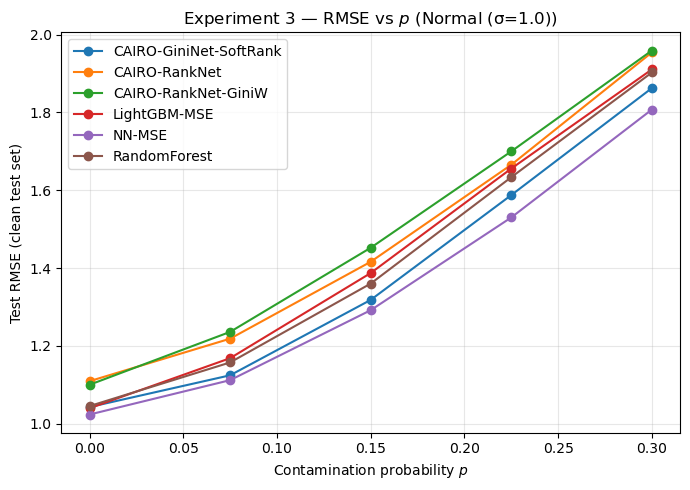

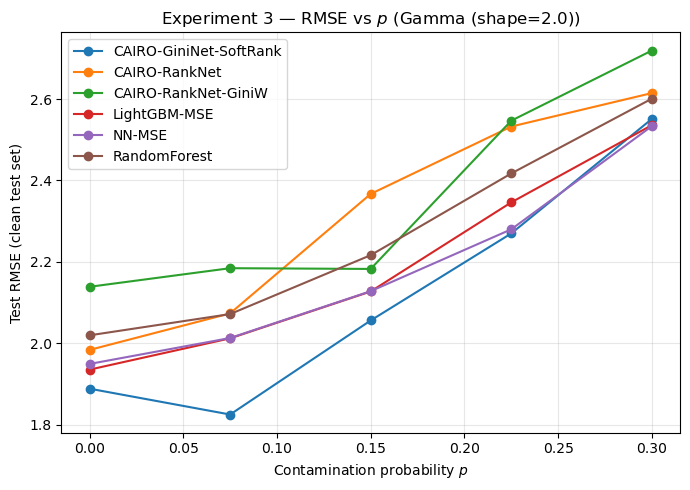

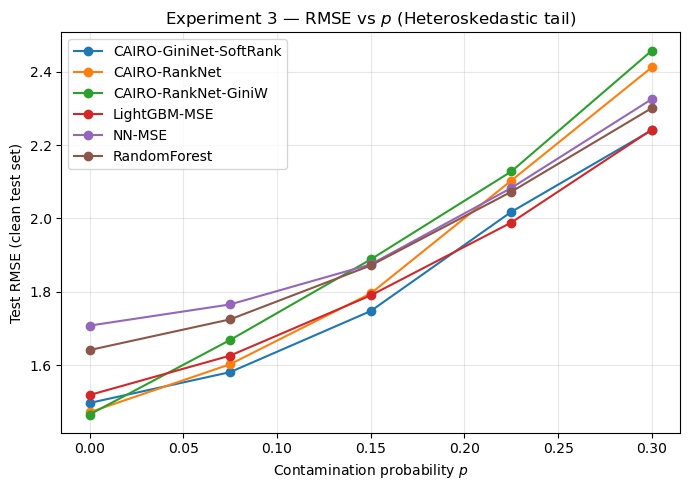

In [35]:
# ===============================================================
# EXPERIMENT 3 — Robustness to Response Contamination
# ===============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# ---------------------------------------------------------------
# Contamination configuration
# ---------------------------------------------------------------
# Grid of contamination probabilities p
CONTAM_PROBS = np.linspace(0.0, 0.3, 5)  # e.g. 0, 0.05, ..., 0.5

# Extra noise added when a point is contaminated:
# epsilon ~ N(EPS_MEAN, EPS_STD^2)
# (change these to get “mean error”, “variance error”, etc.)
EPS_MEAN = 5.0
EPS_STD = 1.0

# Column name for RMSE in your pack_all_metrics dict
# (change to match your implementation if needed)
RMSE_COL = "rmse"

# ---------------------------------------------------------------
# Helper: contaminate training responses
# ---------------------------------------------------------------
def contaminate_responses(y, p, mu_c=EPS_MEAN, sigma_c=EPS_STD, rng=None):
    """
    Return a contaminated copy of y.

    With probability p, add epsilon ~ N(mu_c, sigma_c^2) to each entry.
    With probability (1-p), leave it unchanged.
    """
    if rng is None:
        rng = np.random.default_rng()
    y = np.asarray(y).copy()
    n = y.shape[0]

    mask = rng.random(n) < p
    eps = rng.normal(loc=mu_c, scale=sigma_c, size=n)

    y[mask] = y[mask] + eps[mask]
    return y

# ---------------------------------------------------------------
# Main robustness loop
#   - Same models as Experiment 2
#   - For each scenario and repeat, contaminate training responses
#     with prob p and retrain models
# --------------------------------------------------------------
EXP3_RUNS = []  # one row per (Scenario, ContamProb p, Model, Repeat)

for scen_name, scen_gen in SCENARIOS:
    print(f"\n===== Experiment 3 (Robustness) — Scenario: {scen_name} =====")

    for r in range(N_REPEATS):
        base_seed = SEED + 8000 * r
        print(f"\n--- Repeat {r+1}/{N_REPEATS}, base_seed={base_seed} ---")

        # -------------------------------------------------------
        # Base data (clean)
        # -------------------------------------------------------
        X, y = scen_gen(seed=base_seed)

        # Main train/test split (test set remains CLEAN for all p)
        X_tr_full, X_te, y_tr_full_clean, y_te = train_test_split(
            X, y, test_size=0.3, random_state=base_seed
        )

        d_in = X.shape[1]

        # -------------------------------------------------------
        # Loop over contamination probabilities p
        # -------------------------------------------------------
        for p in CONTAM_PROBS:
            print(f"  > Contamination level p={p:.2f}")

            # RNG tied to scenario, repeat, and p for reproducibility
            rng = np.random.default_rng(base_seed + int(1e4 * p))

            # Contaminate ONLY the training responses
            y_tr_full = contaminate_responses(
                y_tr_full_clean, p, mu_c=EPS_MEAN, sigma_c=EPS_STD, rng=rng
            )

            # Split contaminated training pool into:
            #  - Ranker training + calibration (for CAIRO)
            #  - Regression training + validation (for NN–MSE)
            X_tr_rank, X_cal, y_tr_rank, y_cal = train_test_split(
                X_tr_full, y_tr_full,
                test_size=0.3,
                random_state=base_seed + 1
            )

            X_tr_reg, X_val_reg, y_tr_reg, y_val_reg = train_test_split(
                X_tr_full, y_tr_full,
                test_size=0.2,
                random_state=base_seed + 2
            )

            # ===================================================
            # CAIRO MODELS (Stage 1 ranker + Stage 2 isotonic)
            # ===================================================

            # ---------- CAIRO-RankNet (uniform weights) ----------
            rn_model, _ = train_ranknet_tf_with_curve(
                X_tr_rank, y_tr_rank,
                X_cal, y_cal,
                d_in=d_in,
                pairs_train=PAIRS_TRAIN,
                pairs_val=PAIRS_VAL,
                lr=1e-3,
                epochs=EPOCHS_RANKNET,
                batch_size=BATCH_SIZE,
            )

            s_cal_rn = ranknet_scores_tf(rn_model, X_cal)
            iso_rn = IsotonicRegression(out_of_bounds="clip")
            iso_rn.fit(s_cal_rn, y_cal)

            s_te_rn = ranknet_scores_tf(rn_model, X_te)
            yhat_rn_cairo = iso_rn.predict(s_te_rn)

            EXP3_RUNS.append({
                "Scenario": scen_name,
                "ContamProb": p,
                "Model": "CAIRO-RankNet",
                "Repeat": r,
                **pack_all_metrics(y_te, yhat_rn_cairo),
            })

            # ---------- CAIRO-RankNet-GiniW (gap-weighted RankNet) ----------
            rnw_model, _ = train_ranknet_tf_weighted_with_curve(
                X_tr_rank, y_tr_rank,
                X_cal, y_cal,
                d_in=d_in,
                pairs_train=PAIRS_TRAIN,
                pairs_val=PAIRS_VAL,
                lr=1e-3,
                epochs=EPOCHS_RANKNET,
                batch_size=BATCH_SIZE,
            )

            s_cal_rnw = ranknet_scores_tf(rnw_model, X_cal)
            iso_rnw = IsotonicRegression(out_of_bounds="clip")
            iso_rnw.fit(s_cal_rnw, y_cal)

            s_te_rnw = ranknet_scores_tf(rnw_model, X_te)
            yhat_rnw_cairo = iso_rnw.predict(s_te_rnw)

            EXP3_RUNS.append({
                "Scenario": scen_name,
                "ContamProb": p,
                "Model": "CAIRO-RankNet-GiniW",
                "Repeat": r,
                **pack_all_metrics(y_te, yhat_rnw_cairo),
            })

            # ---------- CAIRO-GiniNet-SoftRank (soft Gini objective) ----------
            gini_model, _ = train_gininet_with_curve(
                X_tr_rank, y_tr_rank,
                X_cal, y_cal,
                epochs=EPOCHS_GINI,
                lr=1e-3,
                batch_size=BATCH_SIZE,
                tau=0.01,
            )

            with torch.no_grad():
                s_cal_gi = gini_model(
                    torch.tensor(X_cal, device=DEVICE, dtype=torch.float32)
                ).cpu().numpy().squeeze()
                s_te_gi = gini_model(
                    torch.tensor(X_te, device=DEVICE, dtype=torch.float32)
                ).cpu().numpy().squeeze()

            iso_gi = IsotonicRegression(out_of_bounds="clip")
            iso_gi.fit(s_cal_gi, y_cal)
            yhat_gi_cairo = iso_gi.predict(s_te_gi)

            EXP3_RUNS.append({
                "Scenario": scen_name,
                "ContamProb": p,
                "Model": "CAIRO-GiniNet-SoftRank",
                "Repeat": r,
                **pack_all_metrics(y_te, yhat_gi_cairo),
            })

            # ===================================================
            # PURE REGRESSION BASELINES
            # ===================================================

            # ---------- NN–MSE ----------
            nn_model = train_mlp_mse(
                X_tr_reg, y_tr_reg,
                X_val_reg, y_val_reg,
                d_in=d_in,
                epochs=EPOCHS_RANKNET,
                batch_size=BATCH_SIZE,
            )
            yhat_nn = nn_model.predict(
                X_te,
                batch_size=BATCH_SIZE,
                verbose=0
            ).squeeze()

            EXP3_RUNS.append({
                "Scenario": scen_name,
                "ContamProb": p,
                "Model": "NN-MSE",
                "Repeat": r,
                **pack_all_metrics(y_te, yhat_nn),
            })

            # ---------- Random Forest ----------
            rf = RandomForestRegressor(
                n_estimators=300 if not DEBUG else 100,
                max_depth=None,
                min_samples_leaf=5,
                n_jobs=-1,
                random_state=base_seed,
            )
            rf.fit(X_tr_full, y_tr_full)  # note: trained on contaminated labels
            yhat_rf = rf.predict(X_te)

            EXP3_RUNS.append({
                "Scenario": scen_name,
                "ContamProb": p,
                "Model": "RandomForest",
                "Repeat": r,
                **pack_all_metrics(y_te, yhat_rf),
            })

            # ---------- LightGBM-MSE ----------
            if HAS_LIGHTGBM:
                lgbm = LGBMRegressor(
                    n_estimators=400 if not DEBUG else 150,
                    learning_rate=0.05,
                    max_depth=-1,
                    num_leaves=31,
                    subsample=0.8,
                    colsample_bytree=0.8,
                    random_state=base_seed,
                    objective="regression",
                )
                lgbm.fit(X_tr_full, y_tr_full)
                yhat_lgbm = lgbm.predict(X_te)

                EXP3_RUNS.append({
                    "Scenario": scen_name,
                    "ContamProb": p,
                    "Model": "LightGBM-MSE",
                    "Repeat": r,
                    **pack_all_metrics(y_te, yhat_lgbm),
                })
            else:
                print("    [Info] Skipping LightGBM (not installed).")

# ---------------------------------------------------------------
# Aggregate results for Experiment 3 (RMSE vs ContamProb)
# ---------------------------------------------------------------
exp3_df = pd.DataFrame(EXP3_RUNS)

with pd.option_context('display.float_format', '{:.3f}'.format):
    print("\n=== Experiment 3: Raw runs (first few rows) ===")
    print(exp3_df.head().to_string(index=False))

# Average RMSE (and other metrics, if you like) over repeats
group_cols = ["Scenario", "Model", "ContamProb"]
agg_rmse = (
    exp3_df
    .groupby(group_cols)['RMSE']
    .agg(["mean", "std", "count"])
    .reset_index()
)

print("\n=== Experiment 3: RMSE summary (per scenario/model/p) ===")
print(agg_rmse.head().to_string(index=False))

# ---------------------------------------------------------------
# Plot RMSE vs p for each Scenario and Model
# ---------------------------------------------------------------
for scen_name in exp3_df["Scenario"].unique():
    scen_df = agg_rmse[agg_rmse["Scenario"] == scen_name]

    plt.figure(figsize=(7, 5))
    for model in sorted(scen_df["Model"].unique()):
        mdf = scen_df[scen_df["Model"] == model]
        plt.plot(
            mdf["ContamProb"],
            mdf["mean"],
            marker="o",
            label=model,
        )

    plt.xlabel("Contamination probability $p$")
    plt.ylabel("Test RMSE (clean test set)")
    plt.title(f"Experiment 3 — RMSE vs $p$ ({scen_name})")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()



=== Experiment 3: Raw runs (first few rows) ===
      Scenario  ContamProb                  Model  Repeat  PairAcc  Spearman  Kendall  NormGini   MSE  RMSE
Normal (σ=1.0)       0.000          CAIRO-RankNet       0    0.712     0.664    0.491     0.684 1.069 1.034
Normal (σ=1.0)       0.000    CAIRO-RankNet-GiniW       0    0.712     0.673    0.499     0.692 1.027 1.013
Normal (σ=1.0)       0.000 CAIRO-GiniNet-SoftRank       0    0.711     0.668    0.497     0.687 1.048 1.024
Normal (σ=1.0)       0.000                 NN-MSE       0    0.755     0.697    0.505     0.718 0.958 0.979
Normal (σ=1.0)       0.000           RandomForest       0    0.745     0.672    0.484     0.695 1.016 1.008

=== Experiment 3: RMSE summary (per scenario/model/p) ===
         Scenario                  Model  ContamProb     mean      std  count
Gamma (shape=2.0) CAIRO-GiniNet-SoftRank       0.000 1.929446 0.634812      5
Gamma (shape=2.0) CAIRO-GiniNet-SoftRank       0.075 1.957356 0.647045      5
Gamma (sha

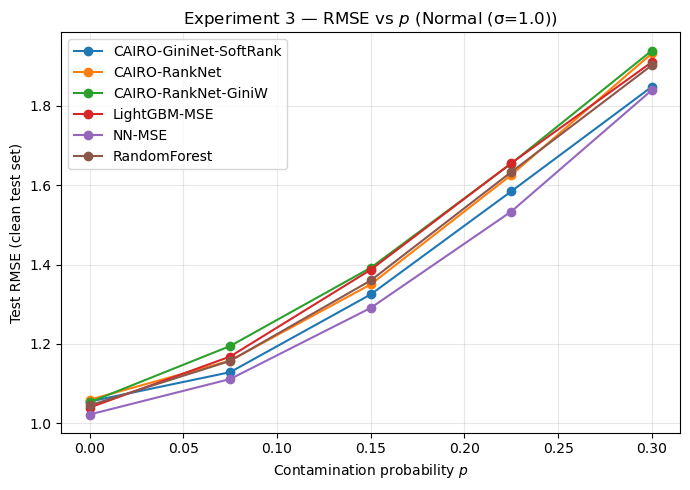

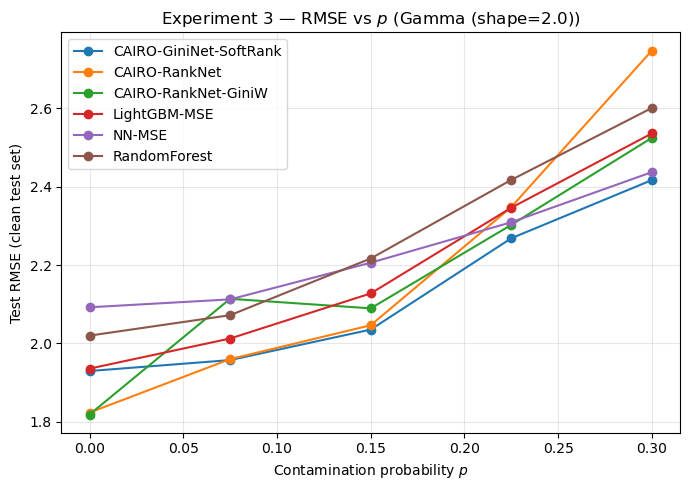

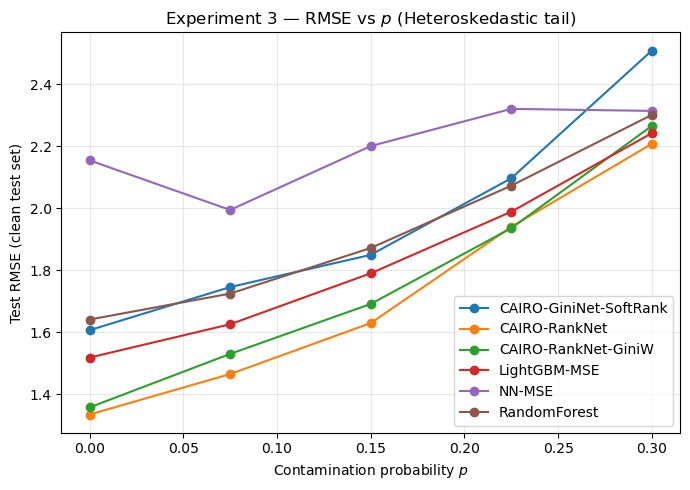

In [32]:
exp3_df = pd.DataFrame(EXP3_RUNS)

with pd.option_context('display.float_format', '{:.3f}'.format):
    print("\n=== Experiment 3: Raw runs (first few rows) ===")
    print(exp3_df.head().to_string(index=False))

# Average RMSE (and other metrics, if you like) over repeats
group_cols = ["Scenario", "Model", "ContamProb"]
agg_rmse = (
    exp3_df
    .groupby(group_cols)['RMSE']
    .agg(["mean", "std", "count"])
    .reset_index()
)

print("\n=== Experiment 3: RMSE summary (per scenario/model/p) ===")
print(agg_rmse.head().to_string(index=False))

# ---------------------------------------------------------------
# Plot RMSE vs p for each Scenario and Model
# ---------------------------------------------------------------
for scen_name in exp3_df["Scenario"].unique():
    scen_df = agg_rmse[agg_rmse["Scenario"] == scen_name]

    plt.figure(figsize=(7, 5))
    for model in sorted(scen_df["Model"].unique()):
        mdf = scen_df[scen_df["Model"] == model]
        plt.plot(
            mdf["ContamProb"],
            mdf["mean"],
            marker="o",
            label=model,
        )

    plt.xlabel("Contamination probability $p$")
    plt.ylabel("Test RMSE (clean test set)")
    plt.title(f"Experiment 3 — RMSE vs $p$ ({scen_name})")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()



=== Experiment 3: Relative RMSE summary ===
         Scenario                  Model  ContamProb  RelRMSE_mean  RelRMSE_std  RelRMSE_n
Gamma (shape=2.0) CAIRO-GiniNet-SoftRank       0.000      1.000000     0.000000          5
Gamma (shape=2.0) CAIRO-GiniNet-SoftRank       0.075      0.956903     0.064628          5
Gamma (shape=2.0) CAIRO-GiniNet-SoftRank       0.150      0.999279     0.075137          5
Gamma (shape=2.0) CAIRO-GiniNet-SoftRank       0.225      1.025972     0.092869          5
Gamma (shape=2.0) CAIRO-GiniNet-SoftRank       0.300      1.096078     0.128907          5


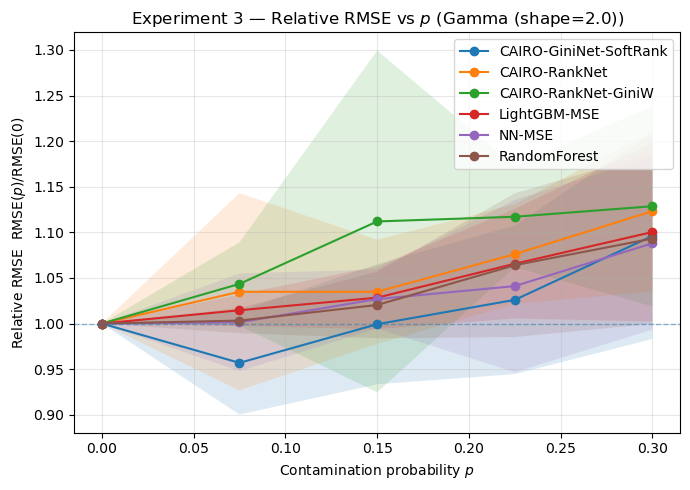

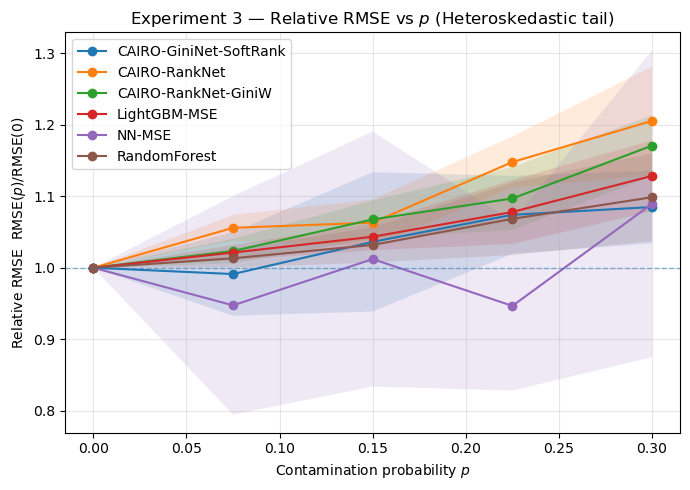

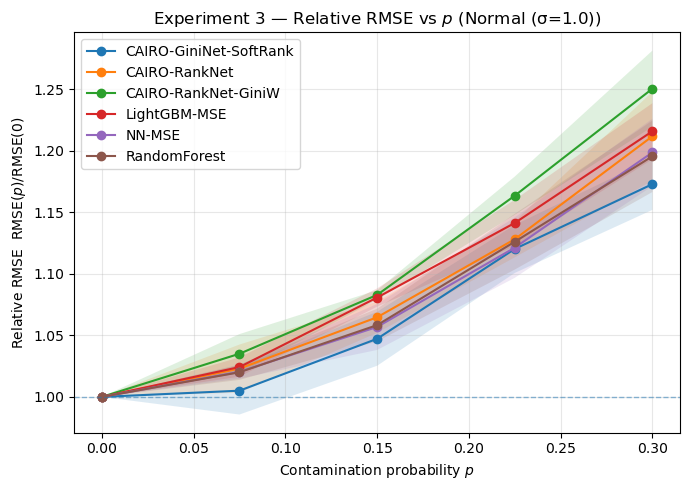

In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# 1. Compute RelRMSE = RMSE(p) / RMSE(0) per repeat
# ---------------------------------------------------------
df = exp3_df.copy()

# Get baseline RMSE at p = 0 for each (Scenario, Model, Repeat)
baseline = (
    df[df["ContamProb"] == 0.0]
    .loc[:, ["Scenario", "Model", "Repeat", "RMSE"]]
    .rename(columns={"RMSE": "RMSE_p0"})
)

# Merge baseline RMSE back onto all rows
df = df.merge(
    baseline,
    on=["Scenario", "Model", "Repeat"],
    how="left",
    validate="many_to_one",
)

# Guard against division by 0 just in case
df["RelRMSE"] = df["RMSE"] / np.clip(df["RMSE_p0"], 1e-8, np.inf)

# ---------------------------------------------------------
# 2. Aggregate RelRMSE over repeats for each (Scenario, Model, p)
# ---------------------------------------------------------
rel_group_cols = ["Scenario", "Model", "ContamProb"]
rel_agg = (
    df.groupby(rel_group_cols)["RelRMSE"]
    .agg(["mean", "std", "count"])
    .reset_index()
    .rename(columns={"mean": "RelRMSE_mean",
                     "std": "RelRMSE_std",
                     "count": "RelRMSE_n"})
)

print("\n=== Experiment 3: Relative RMSE summary ===")
print(rel_agg.head().to_string(index=False))

# ---------------------------------------------------------
# 3. Plot RelRMSE vs p with 95% CI bands
# ---------------------------------------------------------
for scen_name in rel_agg["Scenario"].unique():
    scen_df = rel_agg[rel_agg["Scenario"] == scen_name]

    plt.figure(figsize=(7, 5))
    for model in sorted(scen_df["Model"].unique()):
        mdf = scen_df[scen_df["Model"] == model]

        p_vals = mdf["ContamProb"].values
        mean = mdf["RelRMSE_mean"].values
        std = mdf["RelRMSE_std"].values
        n    = mdf["RelRMSE_n"].values

        # standard error and 95% CI
        se = std / np.sqrt(np.maximum(n, 1))
        lower = mean - 1.96 * se
        upper = mean + 1.96 * se

        # line
        plt.plot(p_vals, mean, marker="o", label=model)
        # shaded CI band
        plt.fill_between(p_vals, lower, upper, alpha=0.15)

    plt.axhline(1.0, linestyle="--", linewidth=1, alpha=0.5)
    plt.xlabel("Contamination probability $p$")
    plt.ylabel("Relative RMSE  $\\mathrm{RMSE}(p) / \\mathrm{RMSE}(0)$")
    plt.title(f"Experiment 3 — Relative RMSE vs $p$ ({scen_name})")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


### LambdaMART + Isotonic for EMTBoost Simul

In [ ]:
# !pip install -q lightgbm scikit-learn scipy numpy pandas

# ================== Quiet + Imports ==================
import os, warnings, logging
import numpy as np
import pandas as pd
from scipy.stats import spearmanr
from sklearn.isotonic import IsotonicRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
import lightgbm as lgb

warnings.filterwarnings("ignore")
logging.getLogger("lightgbm").setLevel(logging.CRITICAL)
if hasattr(lgb, "register_logger"):
    try:
        lgb.register_logger(lambda _: None)
    except Exception:
        pass

def _silent_eval_callback():
    try:
        return lgb.log_evaluation(period=0)
    except Exception:
        try:
            from lightgbm.callback import log_evaluation
            return log_evaluation(period=0)
        except Exception:
            def _noop(env=None): return None
            return _noop

LGBM_SILENT_CALLBACKS = [_silent_eval_callback()]
LGBM_SILENT_KW = dict(verbosity=-1)

# ================== Case 1.1 Generator ==================
def two_hills_two_valleys(x1, x2):
    # F(x1, x2) = exp(-5((1-x1)^2 + x2^2)) + exp(-5(x1^2 + (1-x2)^2))
    return np.exp(-5*((1-x1)**2 + x2**2)) + np.exp(-5*(x1**2 + (1-x2)**2))

def tweedie_compound_poisson(mu, phi=1.0, p=1.5, rng=None):
    if rng is None:
        rng = np.random.default_rng()
    lam = (mu**(2-p)) / (phi*(2-p))
    alpha = (2 - p) / (p - 1)
    theta = phi*(p-1)*(mu**(p-1))
    N = rng.poisson(lam)
    out = np.zeros_like(mu)
    m = N > 0
    if np.any(m):
        idx = np.where(m)[0]
        # Sum of N Gammas(shape=alpha, scale=theta) ~ Gamma(shape=alpha*N, scale=theta)
        out[idx] = rng.gamma(shape=alpha*N[idx], scale=theta[idx])
    return out

def gen_case(q=1.0, n_train=2000, n_val=1000, n_test=5000, phi=1.0, p=1.5, seed=0):
    r = np.random.default_rng(seed)
    def make(n):
        x1 = r.uniform(0,1,n); x2 = r.uniform(0,1,n)
        F  = two_hills_two_valleys(x1, x2)
        mu = np.exp(F)                   # μ(x) = exp(F(x)) per paper
        y  = tweedie_compound_poisson(mu, phi=phi, p=p, rng=r)
        if q < 1.0:
            y = y * (r.random(n) < q)    # zero-inflation
        X = np.column_stack([x1, x2])
        premium = q * mu                 # E[Y|x] used for MAD/Gini eval
        return X, y, premium
    return make(n_train), make(n_val), make(n_test)

# ================== Metrics ==================
def ndcg_at_k(y_true, y_score, k=10):
    order = np.argsort(-y_score)
    rel = y_true[order]
    gains = (2.0**rel - 1.0)
    disc = 1.0/np.log2(np.arange(2, 2+min(k, len(rel))))
    dcg = float(np.sum(gains[:len(disc)] * disc))
    ideal = np.sort(y_true)[::-1]
    idcg = float(np.sum((2.0**ideal[:len(disc)] - 1.0) * disc))
    return dcg/idcg if idcg > 0 else np.nan

def gini_normalized(actual, pred):
    def g(a,p):
        order = np.argsort(-p)
        a = a[order]
        s = a.sum()
        if s == 0: return 0.0
        return np.sum(np.cumsum(a)/s - (np.arange(1,len(a)+1)/len(a)))/len(a)
    gg = g(actual, pred)
    gmax = g(actual, actual)
    return gg/gmax if gmax != 0 else np.nan

# ================== Train-only relevance binning ==================
def fit_relevance_binner(y_train, n_levels):
    edges = np.quantile(y_train, np.linspace(0,1,n_levels+1))
    edges = np.unique(edges)
    if edges.size < 2:
        edges = np.array([y_train.min(), y_train.max()+1e-9])
    return edges

def apply_binner(y, edges):
    internal = edges[1:-1]
    rel = np.digitize(y, internal, right=True).astype(int)
    return np.clip(rel, 0, len(edges)-2)  # 0..L-1

# ================== LambdaMART + Isotonic ==================
def fit_lambdamart(X_tr, y_rel_tr, X_va, y_rel_va, seed, n_estimators, num_leaves, lr):
    model = lgb.LGBMRanker(objective="lambdarank",
                           n_estimators=n_estimators, num_leaves=num_leaves,
                           learning_rate=lr, subsample=0.9, colsample_bytree=0.9,
                           min_data_in_leaf=20, random_state=seed, n_jobs=-1,
                           **LGBM_SILENT_KW)
    model.fit(X_tr, y_rel_tr,
              group=[len(y_rel_tr)],
              eval_set=[(X_va, y_rel_va)],
              eval_group=[[len(y_rel_va)]],
              eval_at=[10], eval_metric="ndcg",
              callbacks=LGBM_SILENT_CALLBACKS)
    return model

def evaluate_pipeline(model, X_va, prem_va, X_te, prem_te):
    s_va = model.predict(X_va); s_te = model.predict(X_te)
    iso = IsotonicRegression(out_of_bounds="clip").fit(s_va, prem_va)
    yhat = iso.transform(s_te)
    mad = float(np.mean(np.abs(prem_te - yhat)))
    mae = float(mean_absolute_error(prem_te, yhat))
    rmse = float(np.sqrt(mean_squared_error(prem_te, yhat)))
    rho = float(spearmanr(prem_te, yhat).correlation)
    ndcg = float(ndcg_at_k(prem_te, yhat, 10))
    gini = float(gini_normalized(prem_te, yhat))
    return mad, mae, rmse, rho, ndcg, gini

# ================== Single-config run (fast & paper-like) ==================
def run_once(q, seed, n_train, n_val, n_test,
             grid_levels=(5,), grid_leaves=(63,), grid_lr=(0.1,), grid_trees=(800,)):
    (X_tr,y_tr,prem_tr),(X_va,y_va,prem_va),(X_te,y_te,prem_te) = gen_case(
        q=q, n_train=n_train, n_val=n_val, n_test=n_test, seed=seed
    )

    best = None
    for L in grid_levels:
        edges = fit_relevance_binner(y_tr, L)          # TRAIN-only edges
        y_rel_tr = apply_binner(y_tr, edges)
        y_rel_va = apply_binner(y_va, edges)
        for nl in grid_leaves:
            for lr in grid_lr:
                for nt in grid_trees:
                    m = fit_lambdamart(X_tr, y_rel_tr, X_va, y_rel_va, seed, nt, nl, lr)
                    s_val = m.predict(X_va)
                    iso_val = IsotonicRegression(out_of_bounds="clip").fit(s_val, prem_va)
                    val_mad = float(np.mean(np.abs(prem_va - iso_val.transform(s_val))))
                    cand = (val_mad, L, nl, lr, nt, edges, m)
                    if (best is None) or (val_mad < best[0]):
                        best = cand

    _, L, nl, lr, nt, edges, model = best
    mad, mae, rmse, rho, ndcg, gini = evaluate_pipeline(model, X_va, prem_va, X_te, prem_te)
    return dict(q=q, seed=seed, L=L, num_leaves=nl, lr=lr, trees=nt,
                MAD=mad, MAE=mae, RMSE=rmse, Spearman=rho, NDCG10=ndcg, GiniNorm=gini)

def run_experiment(qs=(1.0,0.85,0.75,0.50,0.25,0.10), replications=10,
                   n_train=2000, n_val=1000, n_test=5000):
    rows = []
    for q in qs:
        for r in range(replications):
            rows.append(run_once(q=q, seed=1000+r, n_train=n_train, n_val=n_val, n_test=n_test))
    df = pd.DataFrame(rows)
    summary = (df.groupby("q")
                 .agg(MAD_mean=("MAD","mean"), MAD_std=("MAD","std"),
                      GiniNorm_mean=("GiniNorm","mean"), GiniNorm_std=("GiniNorm","std"))
                 .reset_index())
    return df, summary

# ================== Run (replications≈paper) ==================
per_run, by_q = run_experiment(replications=10)
pd.set_option("display.float_format", lambda x: f"{x:0.4f}")
print("Aggregated (your model):\n", by_q, "\n")

# ================== Compare to Yang (Tables) ==================
# Table 1 (MAD) — EMTboost Tuned ρ
emt_mad = {
    1.00: 0.598, 0.85: 0.562, 0.75: 0.503, 0.50: 0.361, 0.25: 0.237, 0.10: 0.124
}
# Table 2 (Gini) — EMTboost Tuned ρ
emt_gini = {
    1.00: 0.481, 0.85: 0.397, 0.75: 0.361, 0.50: 0.292, 0.25: 0.217, 0.10: 0.136
}

cmp = by_q.copy()
cmp["EMT_MAD"]  = cmp["q"].map(emt_mad)
cmp["EMT_Gini"] = cmp["q"].map(emt_gini)
cmp["ΔMAD"]     = cmp["MAD_mean"] - cmp["EMT_MAD"]
cmp["ΔGini"]    = cmp["GiniNorm_mean"] - cmp["EMT_Gini"]
print("Side-by-side vs Yang (positive ΔGini means you’re higher; negative ΔMAD would be better, but scales may differ):\n")
print(cmp[["q","MAD_mean","EMT_MAD","ΔMAD","GiniNorm_mean","EMT_Gini","ΔGini"]])


### Housing example